# 💎 Diamond Price Prediction using Machine Learning

## Project Overview
This project analyzes diamond characteristics and builds machine learning regression models to predict diamond prices. The workflow covers data cleaning, exploratory data analysis, feature preprocessing, model comparison, hyperparameter tuning, and feature importance analysis.

### Objectives
- Understand the characteristics of the diamond dataset.
- Explore relationships between diamond attributes and price.
- Prepare categorical and numerical features for machine learning.
- Compare multiple regression algorithms.
- Tune the best-performing Random Forest model.
- Identify the most important features for price prediction.

### Models
- Linear Regression
- K-Nearest Neighbors (KNN) Regression
- Decision Tree Regression
- Random Forest Regression

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

## 2. Load Dataset

In [2]:
df = pd.read_csv('diamonds.csv')
df.head()

,Index,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
print('Shape:', df.shape)
df.info()

Shape: (53940, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Index    53940 non-null  int64  
 1   carat    53940 non-null  float64
 2   cut      53940 non-null  object 
 3   color    53940 non-null  object 
 4   clarity  53940 non-null  object 
 5   depth    53940 non-null  float64
 6   table    53940 non-null  float64
 7   price    53940 non-null  int64  
 8   x        53940 non-null  float64
 9   y        53940 non-null  float64
 10  z        53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


### Remove the unnecessary index column

The `Index` column is an identifier and does not provide useful information for predicting price.

In [4]:
if 'Index' in df.columns:
    df = df.drop(columns='Index')

df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### Observation
**What was done:** The `Index` column (just a row counter, 1 to 53,940) was dropped because it carries no information about a diamond's price.

**What the output shows:**
- The dataset has **53,940 rows** and **10 columns** left: 3 categorical (`cut`, `color`, `clarity`) and 7 numerical (`carat`, `depth`, `table`, `price`, `x`, `y`, `z`).
- `price` is the target; the other 9 columns are the features.
- `df.info()` earlier showed every column fully filled, so no rows needed to be dropped.

## 3. Data Quality Checks

### 3.1 Check unique values and data types

In [5]:
print(df.dtypes)

for column in df.select_dtypes(include='object').columns:
    print(f"\n{column}: {df[column].unique()}")

carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

cut: ['Ideal' 'Premium' 'Good' 'Very Good' 'Fair']

color: ['E' 'I' 'J' 'H' 'F' 'G' 'D']

clarity: ['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']


### Observation
**What was done:** The data type of every column was printed, and the unique values of each text column were listed.

**What the output shows:**
- `cut` has 5 levels (Fair, Good, Very Good, Premium, Ideal), `color` has 7 (D to J) and `clarity` has 8 (I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF).
- Spellings are consistent, with no stray symbols, blanks or typos, so no text cleaning is needed.
- These categories have a natural quality order, which is why ordinal encoding is used later (Section 5) instead of arbitrary labels.

### 3.2 Duplicate records

In [6]:
duplicate_count = df.duplicated().sum()
print('Duplicate rows:', duplicate_count)

Duplicate rows: 146


### Observation
**What was done:** Fully identical rows were counted with `df.duplicated().sum()`.

**What the output shows:**
- There are **146 duplicate rows** out of 53,940, which is only about **0.27%** of the data.
- They were **kept**. After dropping `Index` there is no ID to prove a row was entered twice, and two different diamonds can genuinely share the same measurements and price.
- With such a small share, keeping or removing them would barely change the models. Class imbalance is not a reason either way, because this is a regression problem.

### 3.3 Missing values

In [7]:
missing_values = df.isnull().sum().sort_values(ascending=False)
print(missing_values)
print('Total missing values:', df.isnull().sum().sum())

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64
Total missing values: 0


### Observation
**What was done:** Missing values were counted in every column.

**What the output shows:**
- All 10 columns have **0 missing values** (total = 0), so no imputation is needed.
- **Caution:** "no missing values" does not mean "all values are valid". The later plots show `x`, `y` and `z` values of exactly **0**, which is physically impossible for a real diamond. These are hidden bad entries, and they are handled in the outlier step (Section 8).

## 4. Exploratory Data Analysis

### 4.1 Numerical feature distributions

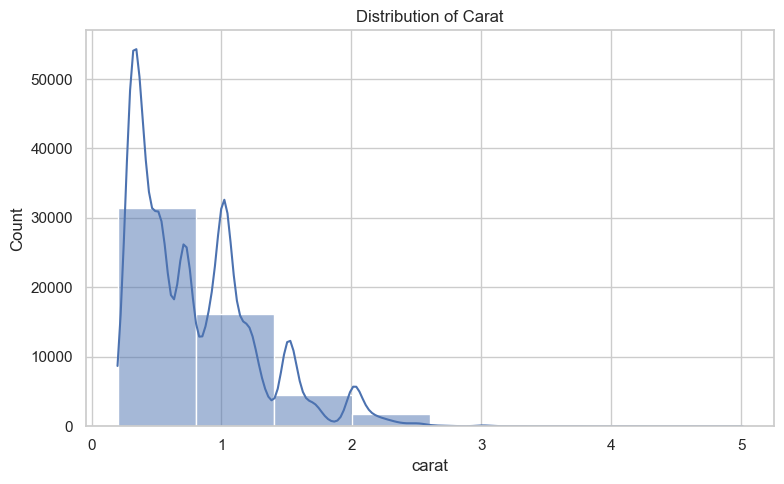

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='carat', bins=8, kde=True)
plt.title('Distribution of Carat')
plt.tight_layout()
plt.show()

**Observation:**
- **What was done:** A histogram with a smooth KDE curve was drawn for `carat` (8 bins).
- **What the plot shows:** The distribution is **right-skewed**. The tallest bar (roughly 0.2 to 0.8 carat) holds about 31,000 diamonds, and counts fall quickly as weight increases. Small bumps in the KDE curve appear near **1, 1.5 and 2 carats**, so round weights are more common. The tail stretches out to 5 carats, but diamonds above 3 carats are very rare.
- **What it means:** Most diamonds in this data are small, so the model sees very few examples of large (and expensive) stones. With only 8 bins the shape is coarse, so the bumps are better seen in the KDE line than in the bars.

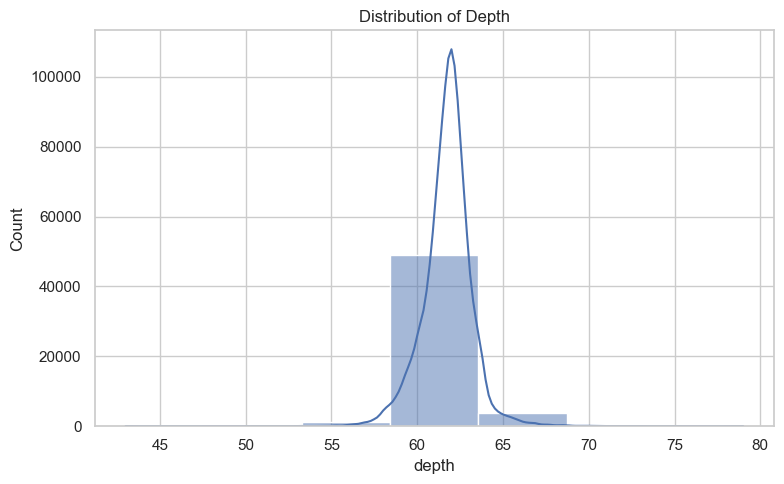

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='depth', bins=7, kde=True)
plt.title('Distribution of Depth')
plt.tight_layout()
plt.show()

**Observation:**
- **What was done:** A histogram with KDE was drawn for `depth` (7 bins).
- **What the plot shows:** The distribution is **bell-shaped and very narrow**, centred at about 61 to 62, with almost all diamonds between roughly 58 and 65. A few extreme values reach as low as about 43 and as high as about 79.
- **What it means:** `depth` hardly varies between diamonds, which hints it will not help much in predicting price (confirmed later by its near-zero correlation with price).

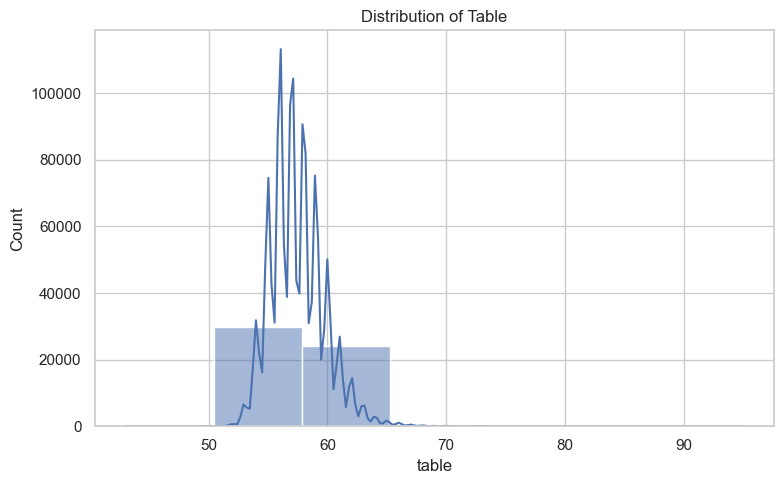

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='table', bins=7, kde=True)
plt.title('Distribution of Table')
plt.tight_layout()
plt.show()

**Observation:**
- **What was done:** A histogram with KDE was drawn for `table` (7 bins).
- **What the plot shows:** Most values lie between about 52 and 66, and two bars hold nearly all the data. The KDE curve is **spiky** because `table` is recorded in whole or half numbers, so the same values repeat. There is a small right tail up to about 95.
- **What it means:** `table` is concentrated in a narrow range with a few extreme values at the high end.

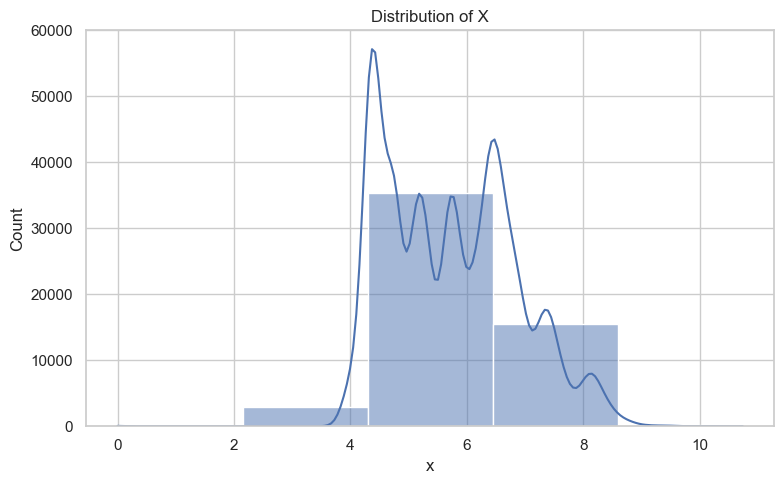

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='x', bins=5, kde=True)
plt.title('Distribution of X')
plt.tight_layout()
plt.show()

**Observation:**
- **What was done:** A histogram with KDE was drawn for `x` (length, 5 bins).
- **What the plot shows:** Most values fall between about 4.3 and 8.5, with several peaks in the KDE curve (a **multi-peaked** shape). The peaks match groups of commonly cut diamond sizes. A few entries sit at **0**, which are invalid.
- **What it means:** `x` follows the carat weight closely (larger stone, larger length), and the zeros are bad records to be treated.

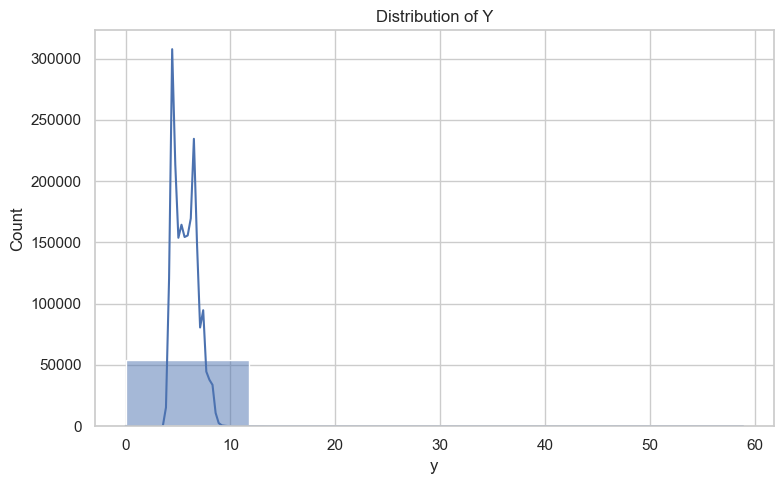

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='y', bins=5, kde=True)
plt.title('Distribution of Y')
plt.tight_layout()
plt.show()

**Observation:**
- **What was done:** A histogram with KDE was drawn for `y` (width, 5 bins).
- **What the plot shows:** Almost every diamond falls into a **single bar**, and the x-axis stretches out to about 60. The real data sits roughly between 4 and 10 (the KDE peaks around 5 to 6). The values near **32 and 59 are extreme**; a 59 mm wide diamond is unrealistic for a dataset whose largest stone is 5 carats, so these look like data-entry errors. There are also zeros.
- **What it means:** A few extreme points squash the histogram, so the real shape is hidden until outliers are treated.

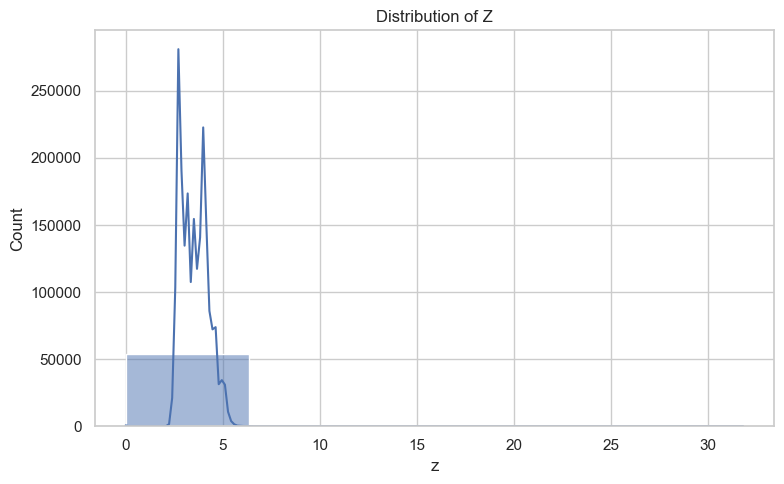

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='z', bins=5, kde=True)
plt.title('Distribution of Z')
plt.tight_layout()
plt.show()

**Observation:**
- **What was done:** A histogram with KDE was drawn for `z` (depth in mm, 5 bins).
- **What the plot shows:** The same pattern as `y`: nearly all diamonds are packed between about 2 and 6, while one extreme value near **32** stretches the axis. There are also entries at **0**.
- **What it means:** `z` has a few clearly invalid values (0 and about 32) that need outlier treatment.

### 4.2 Categorical feature distributions

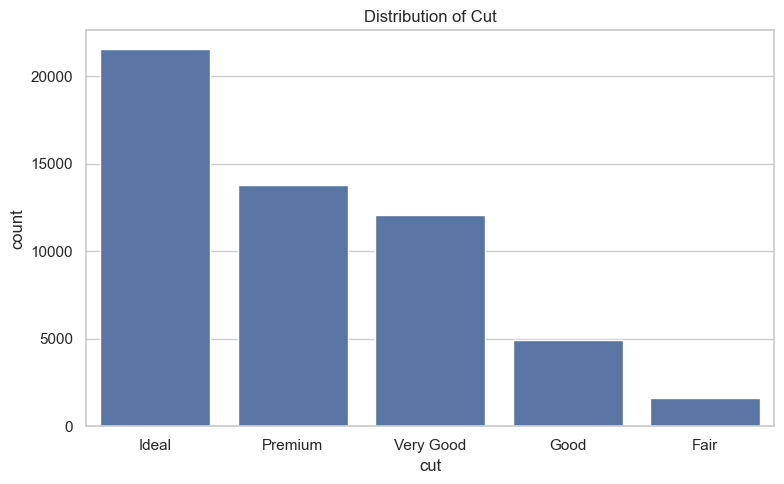

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='cut', order=df['cut'].value_counts().index)
plt.title('Distribution of Cut')
plt.tight_layout()
plt.show()

**Observation:**
- **What was done:** A count plot shows how many diamonds fall in each `cut` category, sorted from most to least common.
- **What the plot shows:** **Ideal** is the most common (about 21,500 diamonds, roughly 40% of the data), followed by Premium (about 13,800) and Very Good (about 12,100). Good (about 4,900) and **Fair (about 1,600)** are much rarer.
- **What it means:** Most stones in the data are well cut, and Fair-cut diamonds have far fewer examples for the model to learn from.

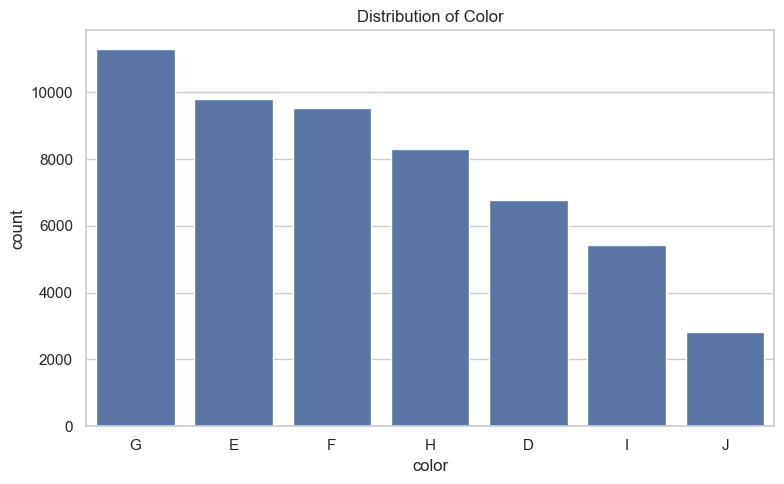

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='color', order=df['color'].value_counts().index)
plt.title('Distribution of Color')
plt.tight_layout()
plt.show()

**Observation:**
- **What was done:** A count plot shows how many diamonds fall in each `color` grade, sorted from most to least common.
- **What the plot shows:** **G** is the most common (about 11,300), followed closely by E and F. **J** is the rarest (about 2,800).
- **What it means:** The middle colour grades dominate, and the lowest grade (J) is the least represented.

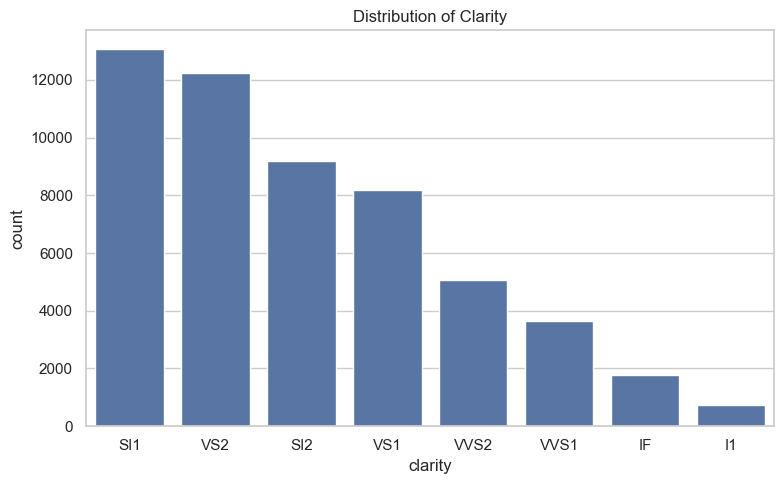

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='clarity', order=df['clarity'].value_counts().index)
plt.title('Distribution of Clarity')
plt.tight_layout()
plt.show()

**Observation:**
- **What was done:** A count plot shows how many diamonds fall in each `clarity` grade, sorted from most to least common.
- **What the plot shows:** **SI1** (about 13,000) and **VS2** (about 12,200) are the most common. The top grade **IF** (about 1,800) and the lowest grade **I1** (about 700) are the rarest.
- **What it means:** Mid-level clarity grades make up most of the data, while the best and worst grades have few examples.

### 4.3 Price relationships

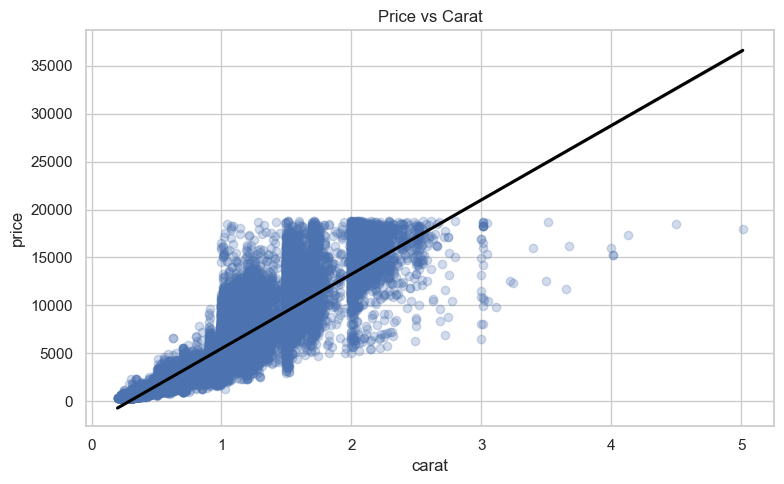

In [17]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='carat', y='price', scatter_kws={'alpha': 0.25}, line_kws={'color': 'black'})
plt.title('Price vs Carat')
plt.tight_layout()
plt.show()

**Observation:**
- **What was done:** A scatter plot of `price` against `carat` with a fitted straight line (regression line).
- **What the plot shows:** There is a **strong positive relationship** (correlation 0.92): heavier diamonds cost more. But it is **not a perfect straight line**:
  - the points fan out, so prices at higher carats vary much more;
  - the line goes below zero for small diamonds, which means a straight line is a poor fit at the low end;
  - **vertical stripes at about 1, 1.5 and 2 carats** show prices jump at round weights;
  - prices stop near $18,800, and a few 3 to 5 carat diamonds are priced below the trend.
- **What it means:** `carat` is the most important feature, but the curved, widening pattern favours non-linear models over Linear Regression. Correlation shows association, not causation.

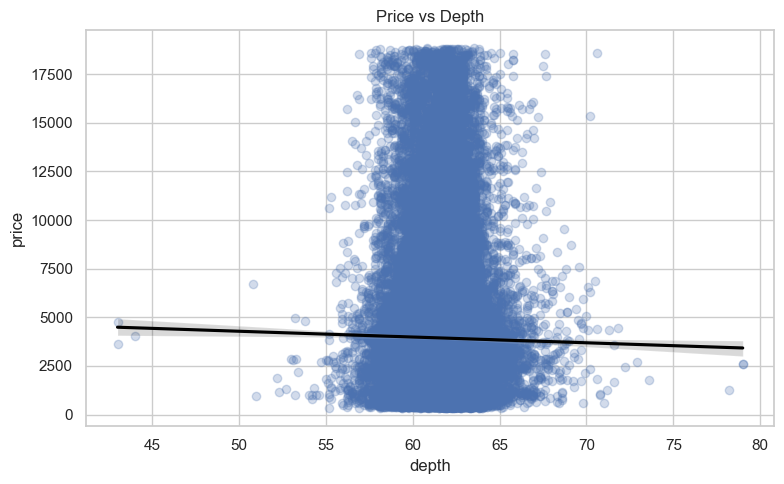

In [18]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='depth', y='price', scatter_kws={'alpha': 0.25}, line_kws={'color': 'black'})
plt.title('Price vs Depth')
plt.tight_layout()
plt.show()

**Observation:**
- **What was done:** A scatter plot of `price` against `depth` with a regression line.
- **What the plot shows:** The points form a **tall vertical band** between about 58 and 66, with prices ranging from the lowest to the highest at almost every depth. The line is nearly **flat** (correlation about -0.01).
- **What it means:** `depth` has **no useful relationship** with price on its own.

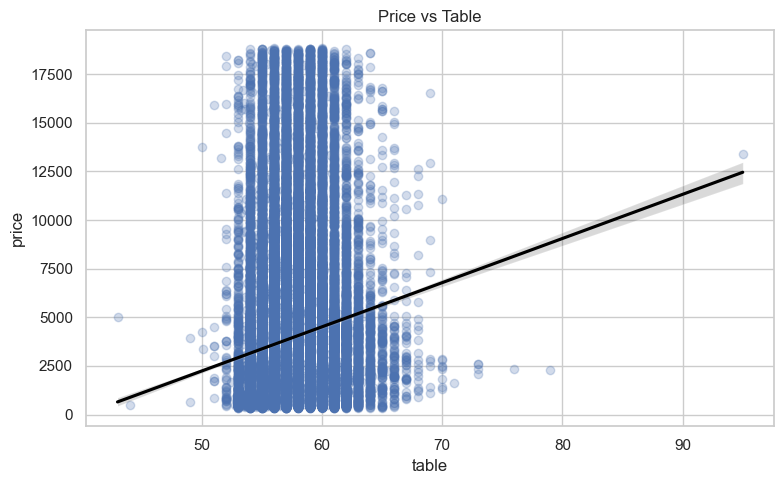

In [19]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='table', y='price', scatter_kws={'alpha': 0.25}, line_kws={'color': 'black'})
plt.title('Price vs Table')
plt.tight_layout()
plt.show()

**Observation:**
- **What was done:** A scatter plot of `price` against `table` with a regression line.
- **What the plot shows:** The points form **vertical stripes** (because `table` takes repeated values) spread across the full price range between about 52 and 65. The line tilts upward only slightly, and that tilt is pulled by a handful of points near 95 (correlation 0.13).
- **What it means:** `table` has only a **weak** link with price.

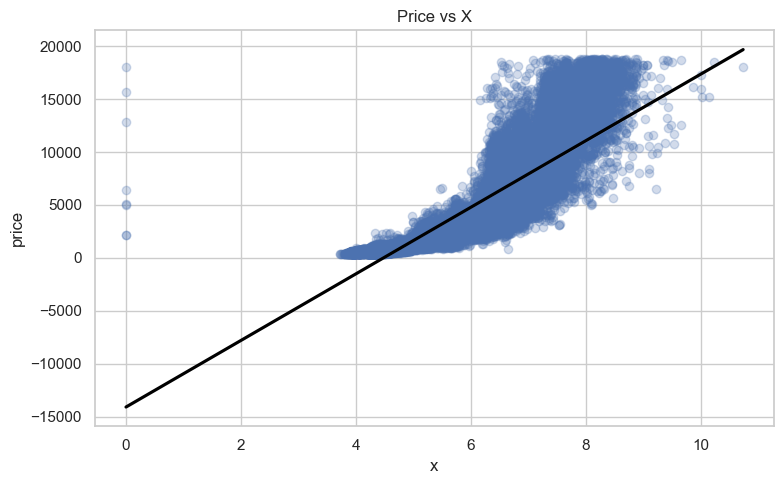

In [20]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='x', y='price', scatter_kws={'alpha': 0.25}, line_kws={'color': 'black'})
plt.title('Price vs X')
plt.tight_layout()
plt.show()

**Observation:**
- **What was done:** A scatter plot of `price` against `x` (length) with a regression line.
- **What the plot shows:** A **strong, curved** relationship (correlation 0.88): price rises slowly for small `x` and much faster beyond about 6 mm. The straight line drops to a negative price at small `x`, again showing a straight line does not fit well. A few points at **x = 0** have prices in the thousands, which are invalid records.
- **What it means:** `x` is a strong predictor, but it is closely tied to `carat` (a bigger stone is physically longer).

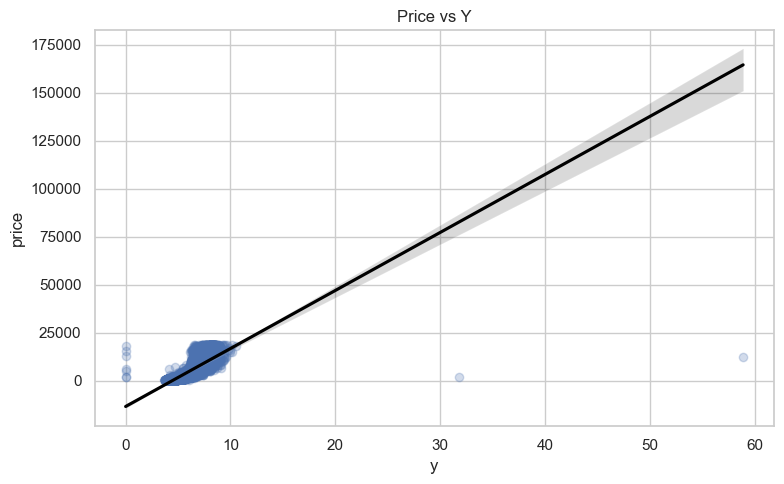

In [21]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='y', y='price', scatter_kws={'alpha': 0.25}, line_kws={'color': 'black'})
plt.title('Price vs Y')
plt.tight_layout()
plt.show()

**Observation:**
- **What was done:** A scatter plot of `price` against `y` (width) with a regression line.
- **What the plot shows:** The real data forms a tight, curved band between about 4 and 10 mm (correlation 0.87). Two extreme points (near **32** and **59**) drag the regression line up to more than 150,000, far above any real price, and there are also points at 0.
- **What it means:** This plot shows how **sensitive a straight-line fit is to outliers**: two bad rows distort the whole line. This is the main reason outlier treatment is needed.

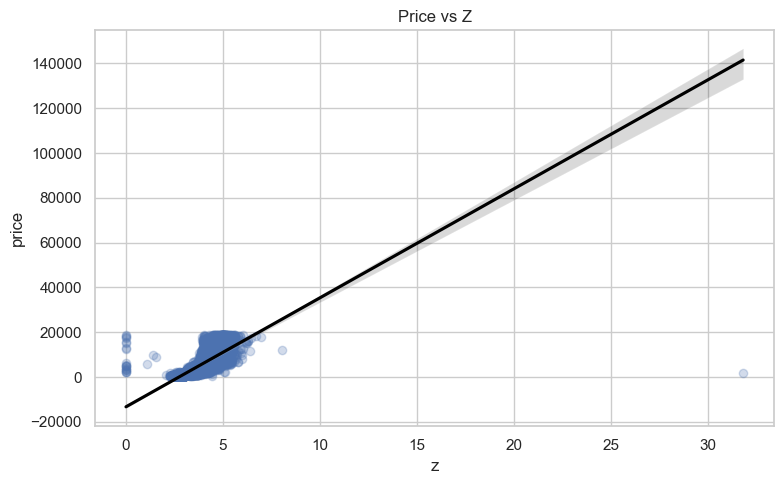

In [22]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='z', y='price', scatter_kws={'alpha': 0.25}, line_kws={'color': 'black'})
plt.title('Price vs Z')
plt.tight_layout()
plt.show()

**Observation:**
- **What was done:** A scatter plot of `price` against `z` (depth in mm) with a regression line.
- **What the plot shows:** The same story as `y`: a tight, curved band at about 2 to 6 mm (correlation 0.86), one extreme point near **32** that pulls the line up to about 140,000, and some points at 0.
- **What it means:** `z` is a strong predictor once its few invalid values are treated.

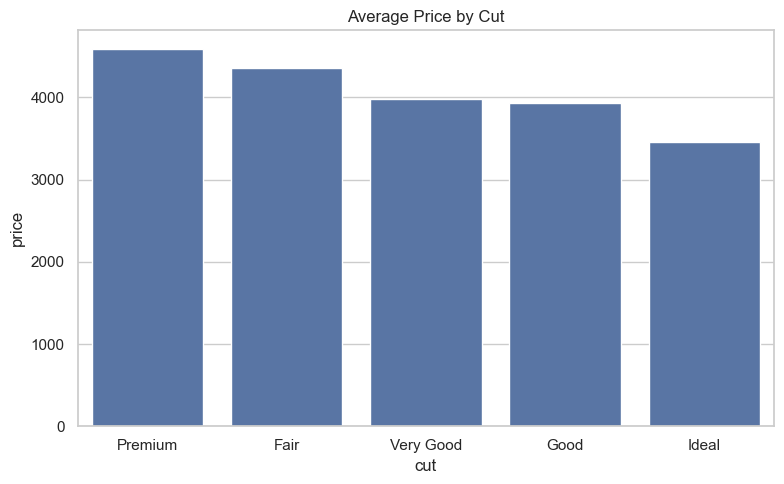

In [23]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='cut', y='price', estimator='mean', errorbar=None, order=df.groupby('cut')['price'].mean().sort_values(ascending=False).index)
plt.title('Average Price by Cut')
plt.tight_layout()
plt.show()

**Observation:**
- **What was done:** A bar chart of the **average price** for each `cut`, with the exact values printed in the next cell.
- **What the plot shows:** **Premium** has the highest average price (about $4,584), then Fair ($4,359), Very Good ($3,982), Good ($3,929), and **Ideal has the lowest ($3,458)**.
- **What it means:** The best cut is *not* the most expensive on average, so `cut` alone does not explain price. A likely reason is that the average carat differs between cut groups (a bigger Fair or Premium stone can cost more than a smaller Ideal one), but this notebook does not check that directly.

In [24]:
print(df.groupby('cut')['price'].mean().sort_values(ascending=False))

cut
Premium      4584.257704
Fair         4358.757764
Very Good    3981.759891
Good         3928.864452
Ideal        3457.541970
Name: price, dtype: float64


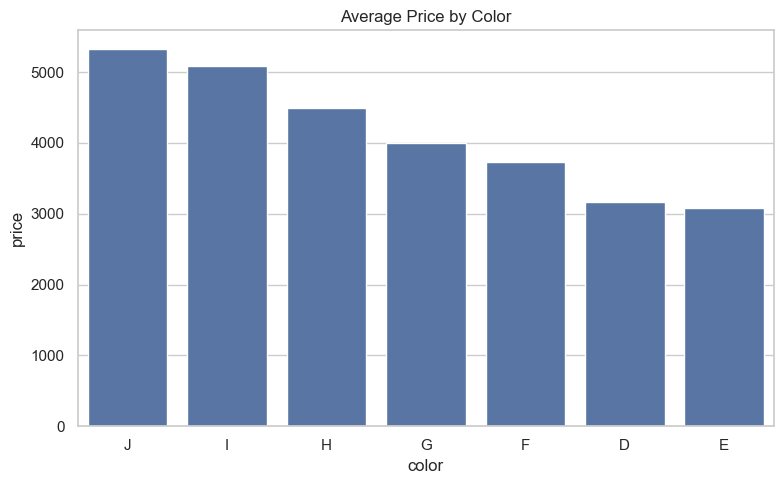

In [25]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='color', y='price', estimator='mean', errorbar=None, order=df.groupby('color')['price'].mean().sort_values(ascending=False).index)
plt.title('Average Price by Color')
plt.tight_layout()
plt.show()

**Observation:**
- **What was done:** A bar chart of the **average price** for each `color`, with the exact values printed in the next cell.
- **What the plot shows:** Prices **fall from J to E**: J is highest (about $5,324), then I ($5,092), H ($4,487), G ($3,999), F ($3,725), D ($3,170), and **E lowest ($3,077)**.
- **What it means:** J is the *worst* colour grade and D the *best*, yet the worst grade has the highest average price. So colour is hiding another factor, most likely carat (larger stones tend to have lower colour grades). Colour only makes sense when read together with size.

In [26]:
print(df.groupby('color')['price'].mean().sort_values(ascending=False))

color
J    5323.818020
I    5091.874954
H    4486.669196
G    3999.135671
F    3724.886397
D    3169.954096
E    3076.752475
Name: price, dtype: float64


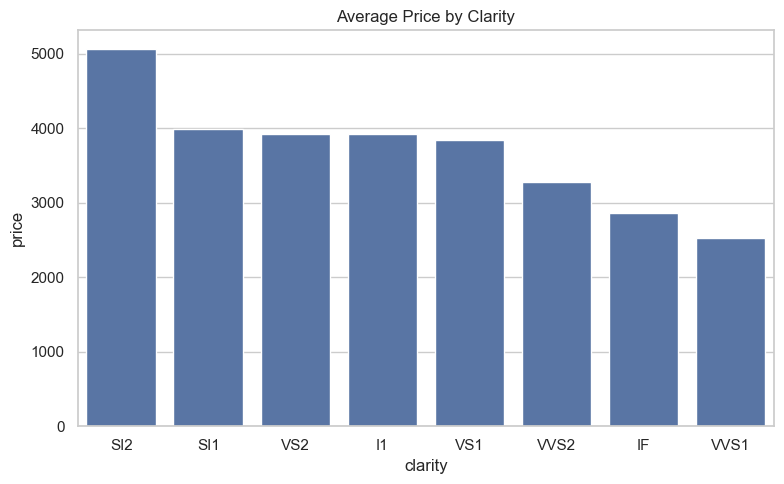

In [27]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='clarity', y='price', estimator='mean', errorbar=None, order=df.groupby('clarity')['price'].mean().sort_values(ascending=False).index)
plt.title('Average Price by Clarity')
plt.tight_layout()
plt.show()

**Observation:**
- **What was done:** A bar chart of the **average price** for each `clarity`, with the exact values printed in the next cell.
- **What the plot shows:** **SI2** has the highest average (about $5,063). SI1, VS2, I1 and VS1 are close together (about $3,840 to $3,996), then VVS2 ($3,284), IF ($2,865) and **VVS1 lowest ($2,523)**.
- **What it means:** The order does not follow clarity quality: the two best grades (VVS1, IF) have the lowest averages. As with colour, the grade on its own is misleading, and **carat is the main driver of price**.

In [28]:
print(df.groupby('clarity')['price'].mean().sort_values(ascending=False))

clarity
SI2     5063.028606
SI1     3996.001148
VS2     3924.989395
I1      3924.168691
VS1     3839.455391
VVS2    3283.737071
IF      2864.839106
VVS1    2523.114637
Name: price, dtype: float64


### 4.4 Correlation analysis

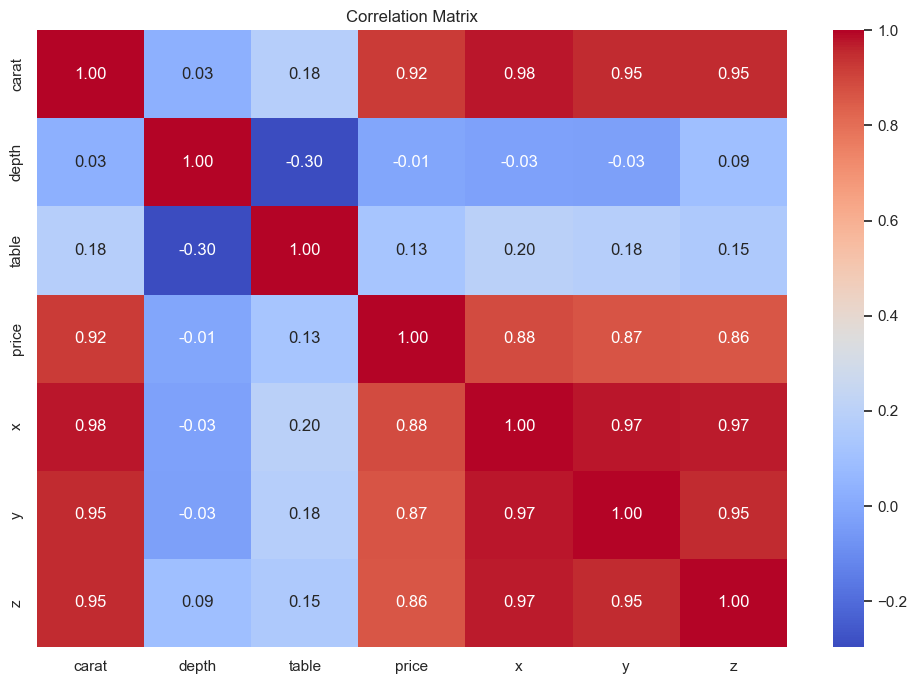

In [29]:
numeric_df = df.select_dtypes(include='number')
df_corr = numeric_df.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(df_corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

**Observation:**
- **What was done:** A correlation matrix (heatmap) was drawn for the 7 numerical columns. Values range from -1 to +1.
- **What the plot shows:**
  - `price` is strongly positively correlated with `carat` (**0.92**), `x` (0.88), `y` (0.87) and `z` (0.86).
  - `price` is almost unrelated to `table` (0.13) and `depth` (-0.01).
  - `carat`, `x`, `y` and `z` are **highly correlated with each other** (0.95 to 0.98), because they all measure the size of the diamond.
  - `depth` and `table` are mildly negatively correlated (-0.30).
- **What it means:** Size drives price. Because the four size columns carry almost the same information (**multicollinearity**), Linear Regression coefficients can be unstable, and tree models will share importance between them. Correlation measures only linear association, not causation, and the text columns (`cut`, `color`, `clarity`) are not included here.

## 5. Prepare Features and Target

In [30]:
X = df.drop(columns='price').copy()
y = df['price'].copy()

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (53940, 9)
y shape: (53940,)


**Observation:** `price` was separated as the target (`y`) and the other 9 columns became the features (`X`). Both have 53,940 rows (`X` shape: 53,940 x 9; `y`: 53,940).

### Encode ordinal categorical variables

`cut`, `color`, and `clarity` have meaningful domain-specific orderings, so ordinal mappings are used instead of arbitrary label encoding.

In [31]:
cut_num = {
    'Fair': 1,
    'Good': 2,
    'Very Good': 3,
    'Ideal': 4,
    'Premium': 5
}

color_num = {
    'J': 1,
    'I': 2,
    'H': 3,
    'G': 4,
    'F': 5,
    'E': 6,
    'D': 7
}

clarity_num = {
    'I1': 1,
    'SI2': 2,
    'SI1': 3,
    'VS2': 4,
    'VS1': 5,
    'VVS2': 6,
    'VVS1': 7,
    'IF': 8
}

X['cut'] = X['cut'].map(cut_num)
X['color'] = X['color'].map(color_num)
X['clarity'] = X['clarity'].map(clarity_num)

X.head()

,carat,cut,color,clarity,depth,table,x,y,z
0,0.23,4,6,2,61.5,55.0,3.95,3.98,2.43
1,0.21,5,6,3,59.8,61.0,3.89,3.84,2.31
2,0.23,2,6,5,56.9,65.0,4.05,4.07,2.31
3,0.29,5,2,4,62.4,58.0,4.20,4.23,2.63
4,0.31,2,1,2,63.3,58.0,4.34,4.35,2.75


### Observation
**What was done:** The text columns were converted to numbers using ordered dictionaries: `cut` (Fair = 1 up to Premium = 5), `color` (J = 1 up to D = 7) and `clarity` (I1 = 1 up to IF = 8). The first rows confirm it, e.g. row 0 changed from Ideal / E / SI2 to 4 / 6 / 2.

**What the output shows:** All 9 features are now numeric, so every model can use them.

**Point to revisit:** In the `cut` mapping, **Premium (5) is ranked above Ideal (4)**. Diamond grading usually ranks Ideal as the best cut, so the usual order is Fair, Good, Very Good, Premium, Ideal. The wrong order mainly affects Linear Regression and KNN, which treat the numbers as distances; tree models are less affected.

## 6. Train-Test Split

The split is performed **before scaling** to prevent information from the test set from leaking into the training process.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train: (43152, 9)
X_test : (10788, 9)
y_train: (43152,)
y_test : (10788,)


**Observation:** The data was split **80% / 20%** into 43,152 training rows and 10,788 test rows (`random_state=42` makes the split repeatable). The test rows are kept unseen so the final scores reflect new data.

## 7. Scale Numerical Features Without Data Leakage

The scaler is fitted only on `X_train` and then used to transform both training and test data.

In [33]:
numeric_cols = X_train.select_dtypes(include='number').columns

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train_scaled.head()

,carat,cut,color,clarity,depth,table,x,y,z
26546,2.560056,-1.718100,0.347949,-1.246901,-2.550748,2.933861,2.229450,2.138209,1.738207
9159,0.447392,-0.742465,0.936621,-1.246901,-1.220426,1.139575,0.747550,0.656710,0.537733
14131,0.637532,1.208804,-0.829396,-0.032134,0.529996,0.242432,0.765404,0.700284,0.791951
15757,1.482597,-1.718100,0.936621,-1.246901,-0.170173,3.382432,1.318885,1.249310,1.243894
24632,1.524851,-0.742465,-0.240724,0.575249,0.249928,-0.206140,1.372448,1.380030,1.399249


### Observation
**What was done:** `StandardScaler` was fitted on the **training data only**, then used to transform both train and test sets, so each column now has a mean of about 0 and a standard deviation of about 1. All 9 columns were scaled, including the encoded ones.

**What the output shows:** The values in `X_train_scaled.head()` are now small positive and negative numbers. For example, the first row has carat = 2.56 and depth = -2.55, meaning it is about 2.5 standard deviations above the average carat and below the average depth.

**Why it matters:** Scaling helps Linear Regression and KNN (they depend on the size of the numbers) but is not needed for tree-based models. These scaled copies were made **before** the outlier step in Section 8, so they still contain the original (unclipped) outliers.

## 8.Outlier Treatment.

In [34]:
def treat_outliers_iqr(df, column, show_plot=True):
    if show_plot:
        plt.figure(figsize=(15, 5))
        sns.boxplot(x=df[column])
        plt.title(f"Before Outlier Treatment: {column}")
        plt.show()

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    if IQR == 0:
        print(f"[INFO] No IQR variation for column '{column}'. Skipping outlier treatment.")
        return df

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_before = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    df.loc[:, column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    outliers_after = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    print(f"[{column}] Outliers before: {outliers_before}, after: {outliers_after}")

    
    if show_plot:
        plt.figure(figsize=(15, 5))
        sns.boxplot(x=df[column])
        plt.title(f"After Outlier Treatment: {column}")
        plt.show()

    return df

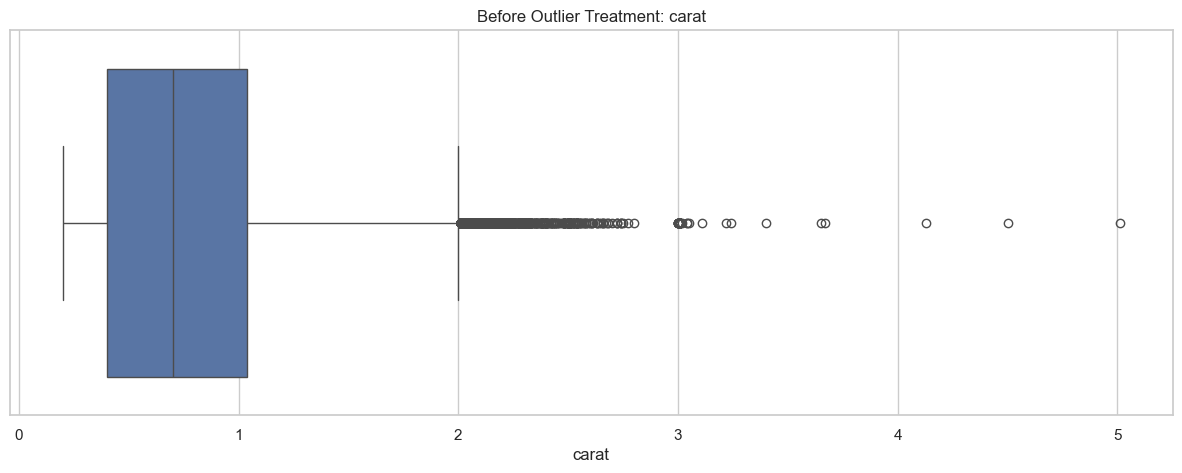

[carat] Outliers before: 1510, after: 0


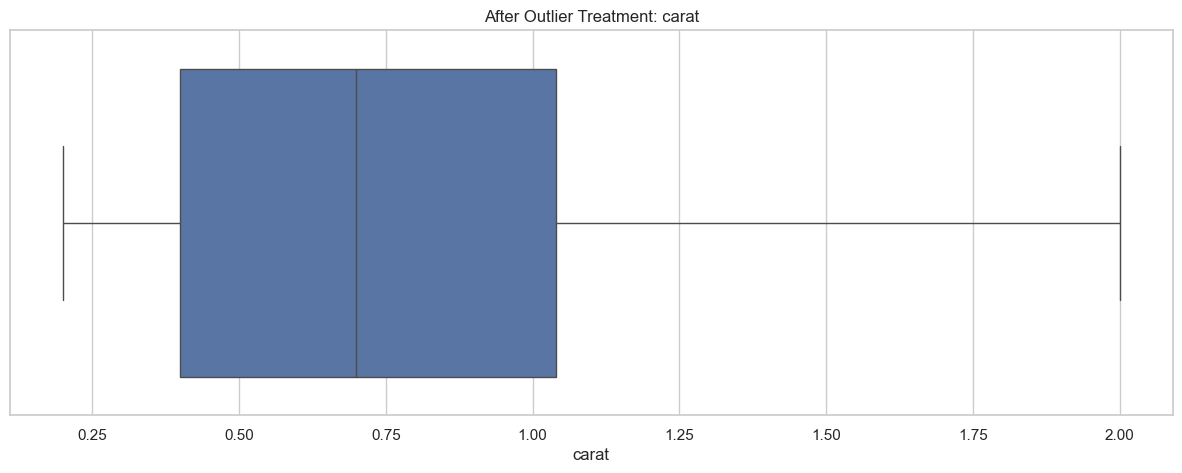

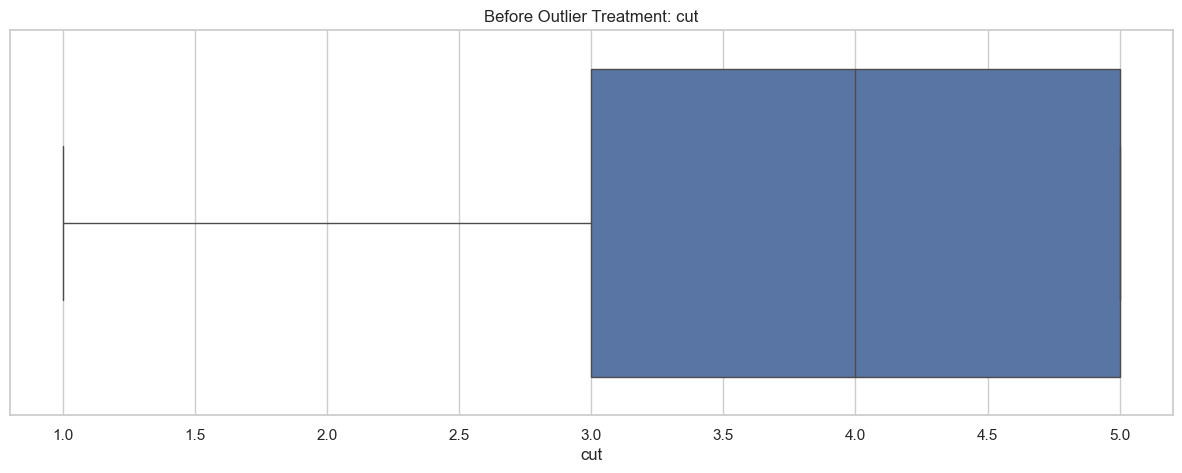

[cut] Outliers before: 0, after: 0


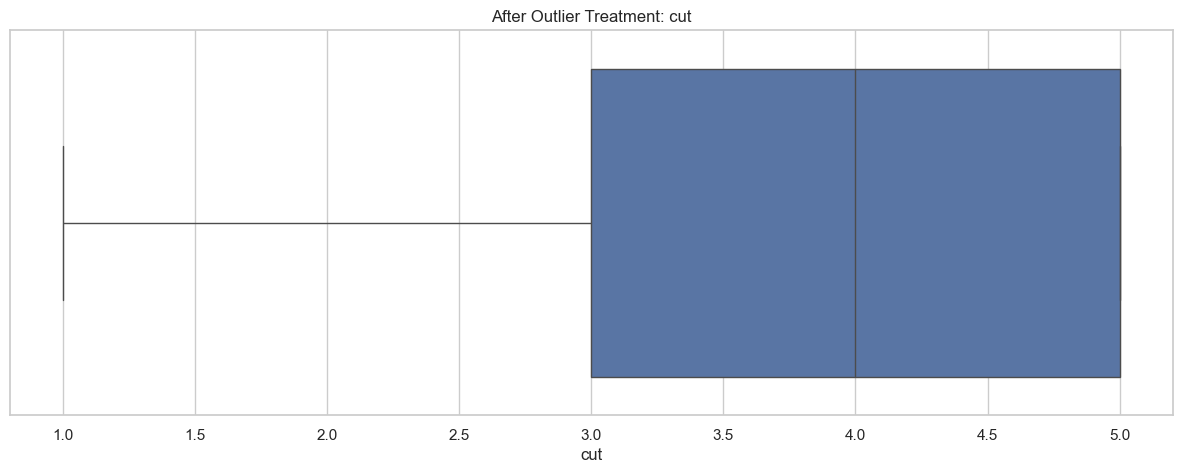

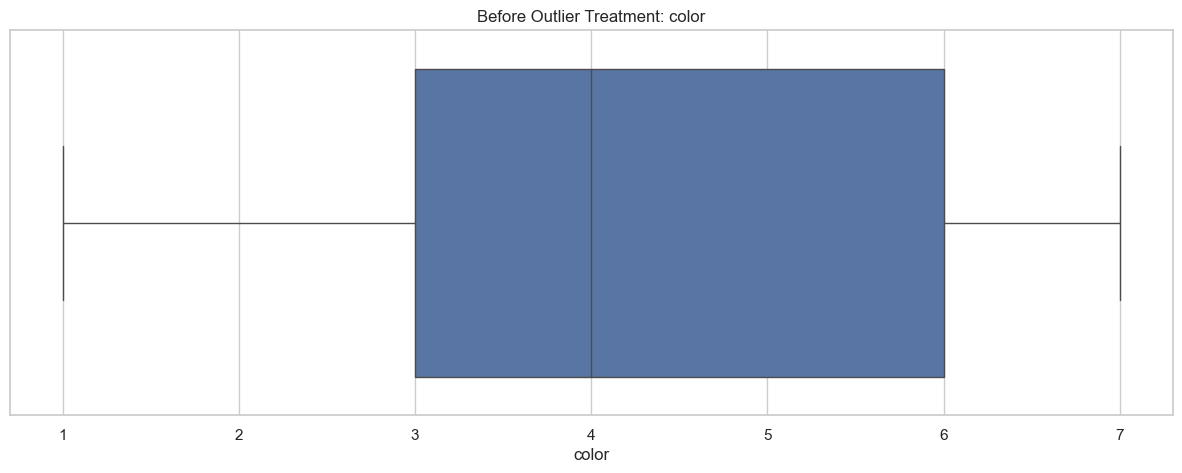

[color] Outliers before: 0, after: 0


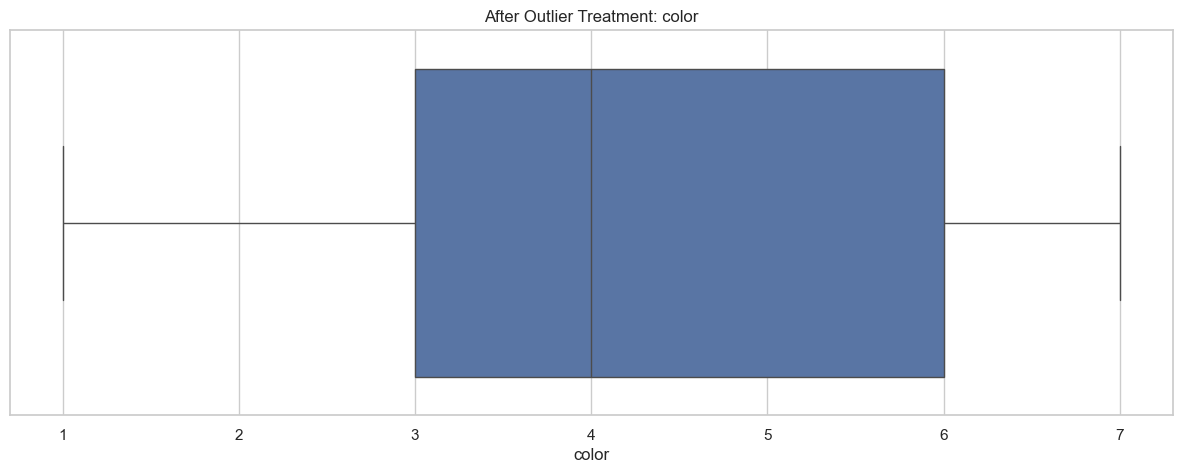

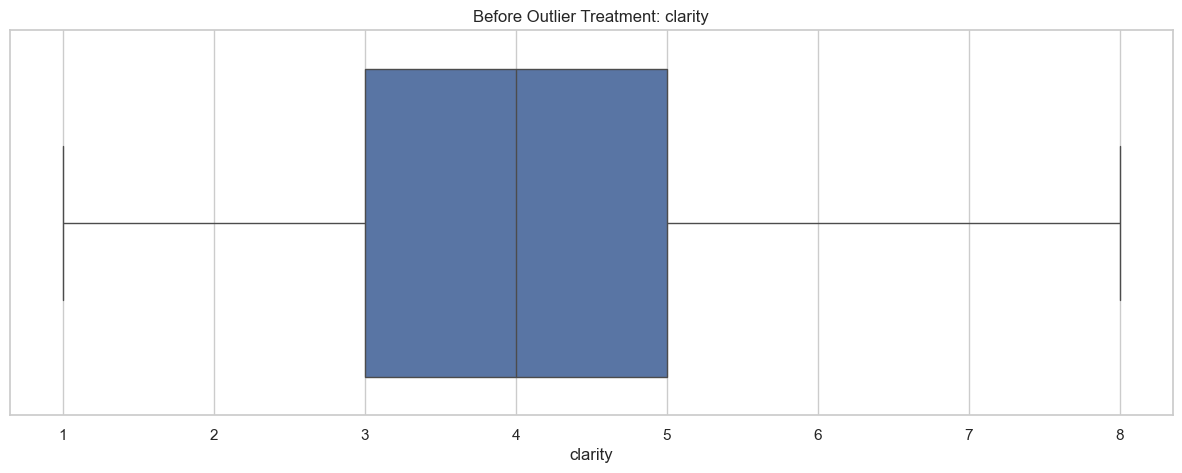

[clarity] Outliers before: 0, after: 0


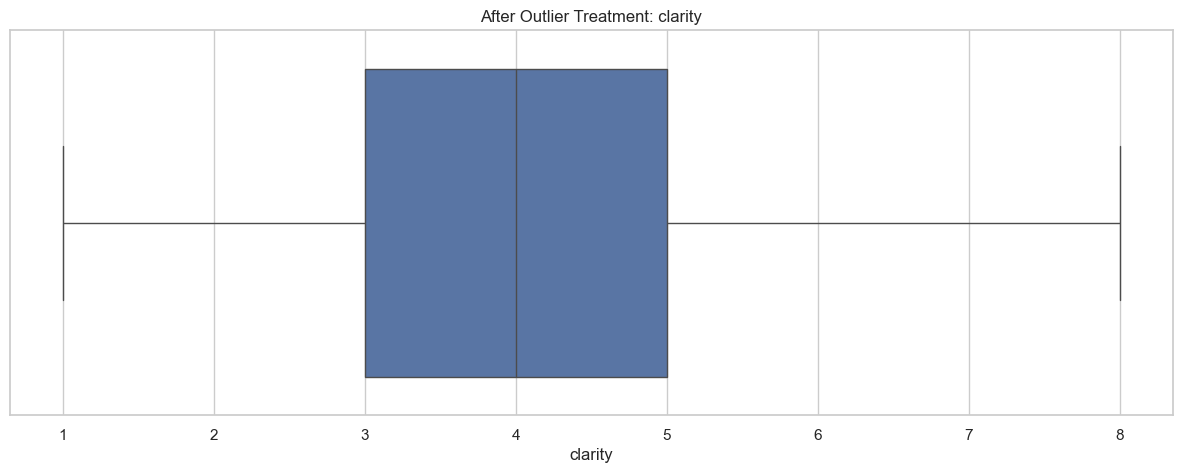

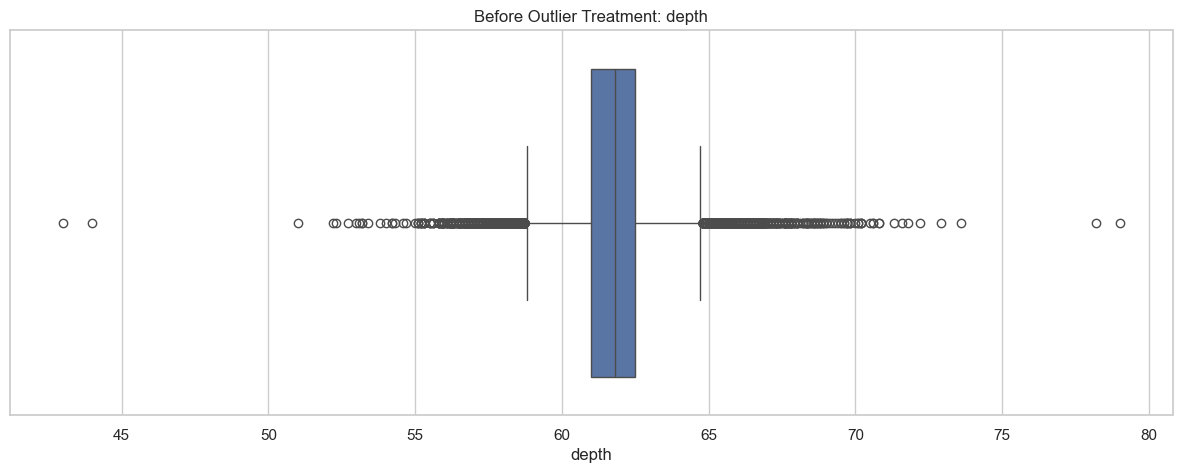

[depth] Outliers before: 2020, after: 0


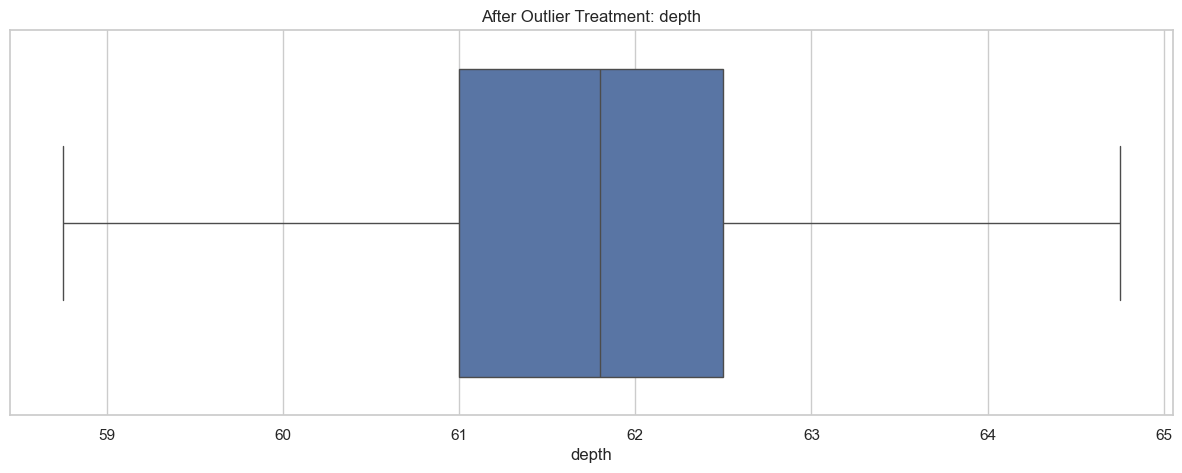

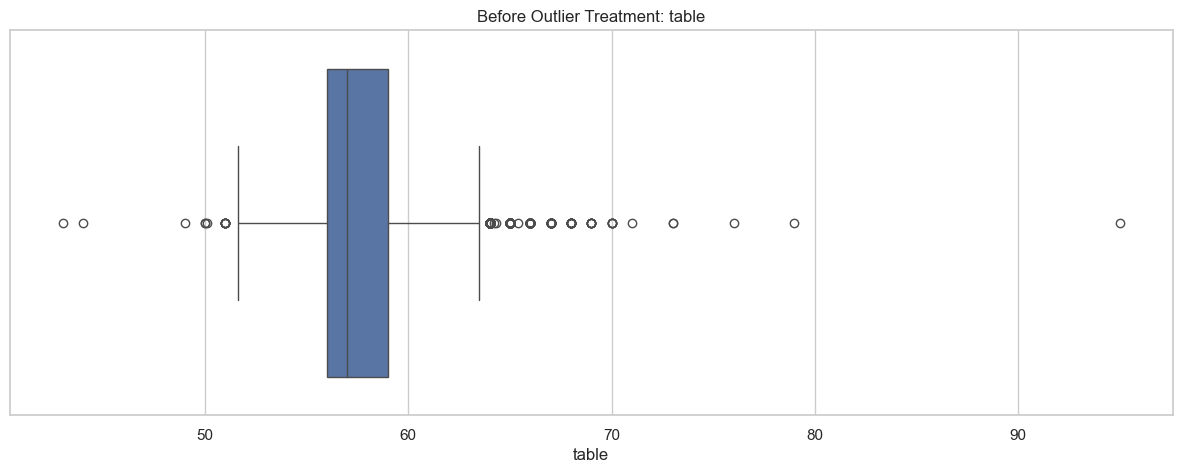

[table] Outliers before: 479, after: 0


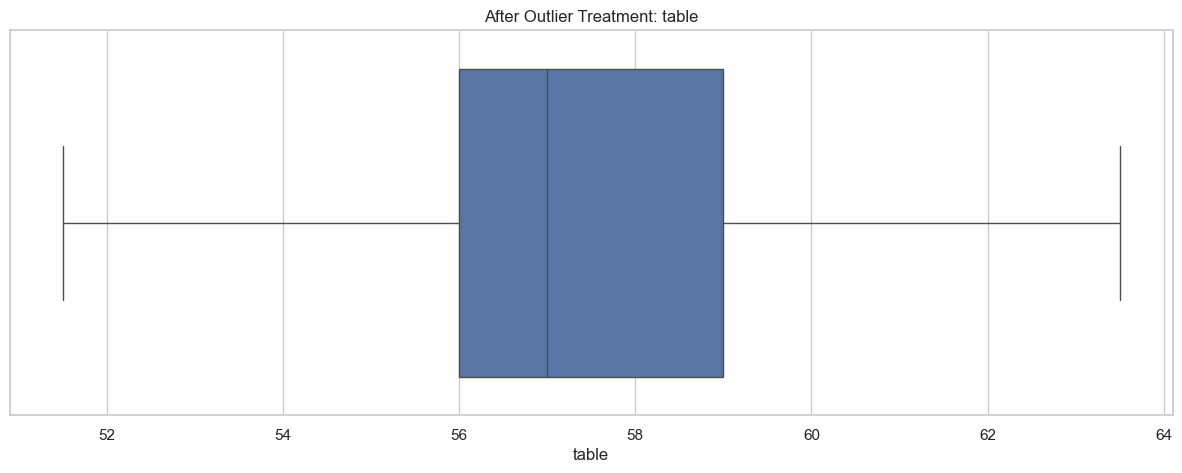

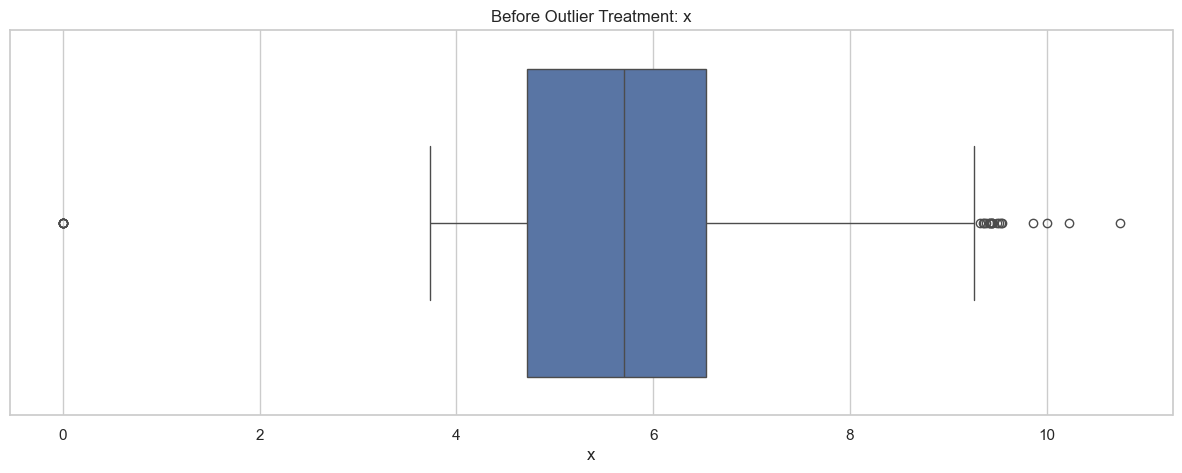

[x] Outliers before: 25, after: 0


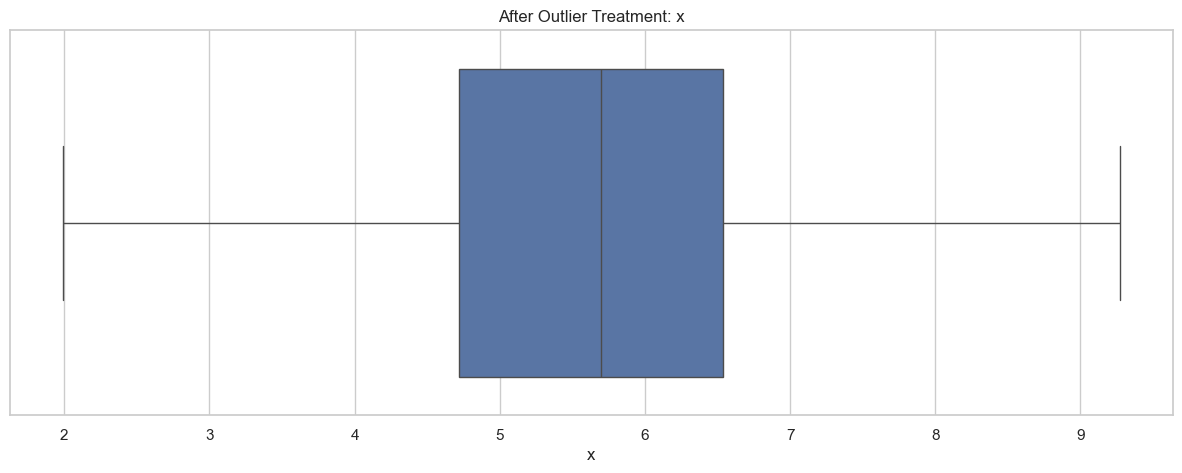

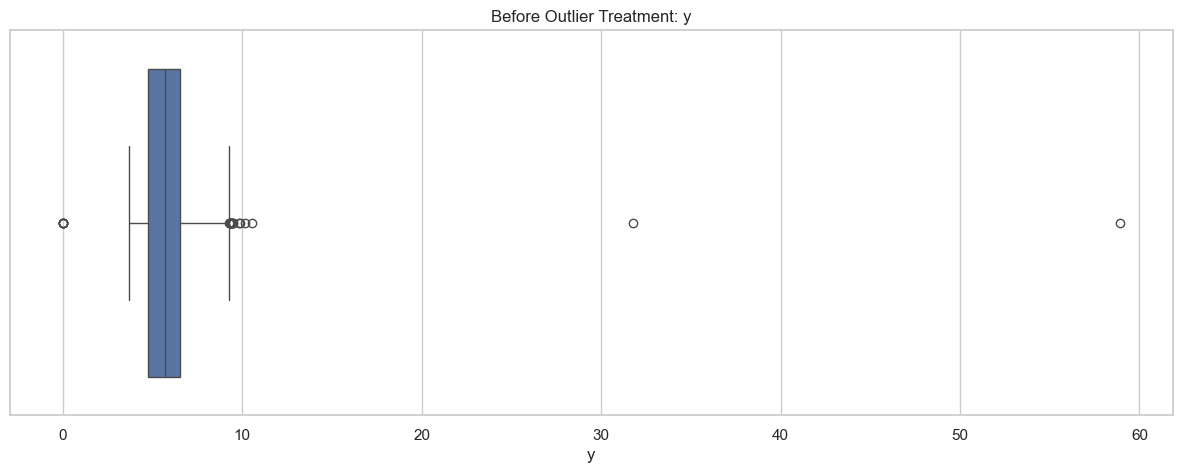

[y] Outliers before: 24, after: 0


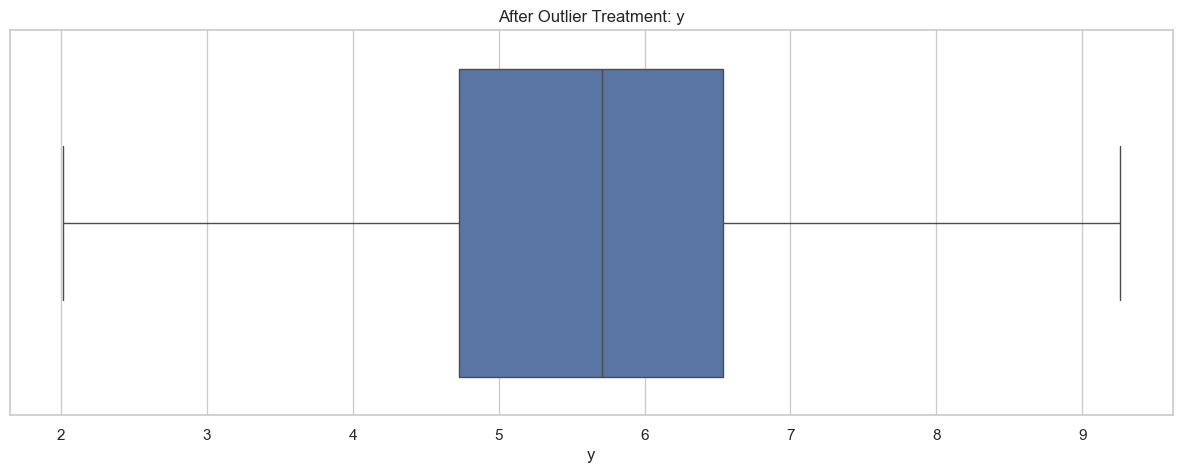

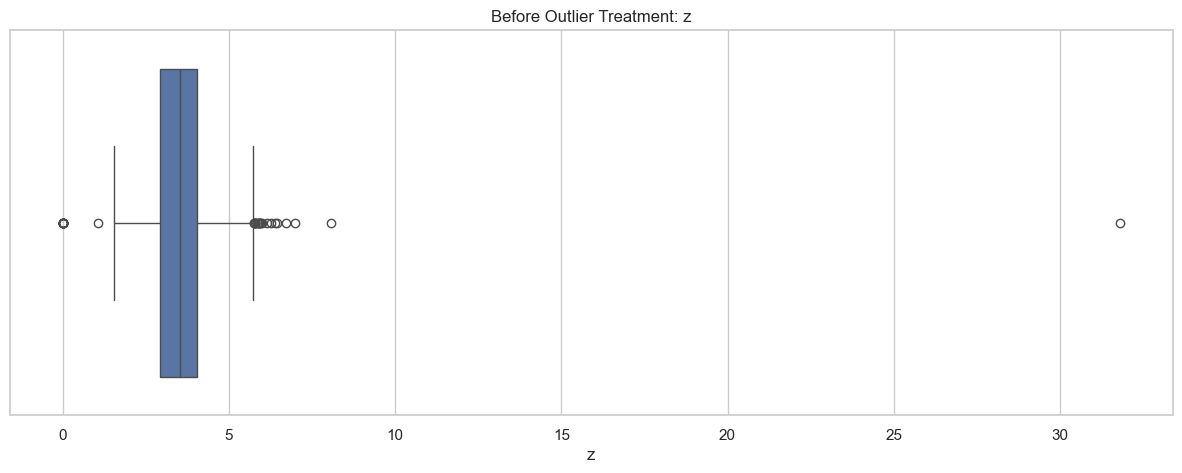

[z] Outliers before: 42, after: 0


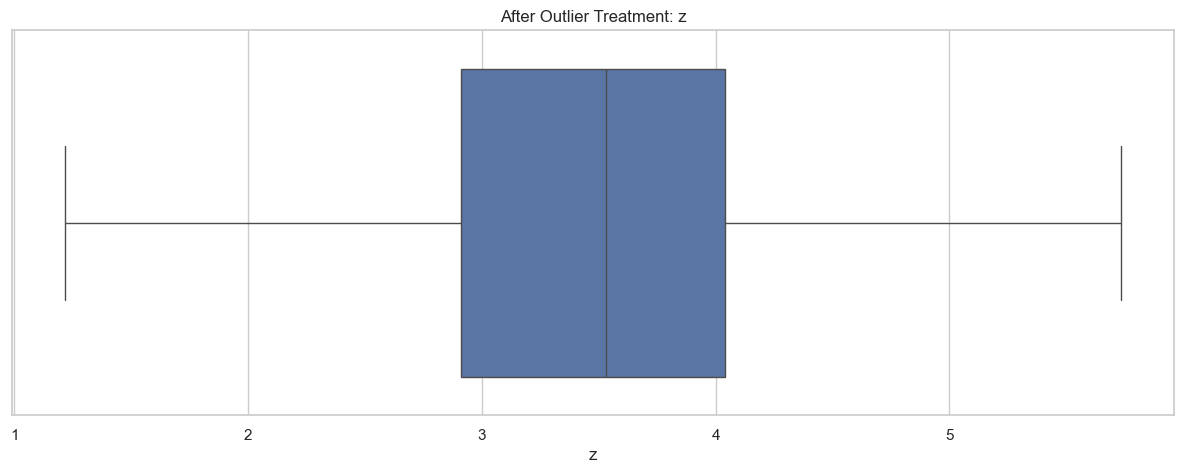

In [35]:
for i in X_train.columns:
    treat_outliers_iqr(X_train, i)

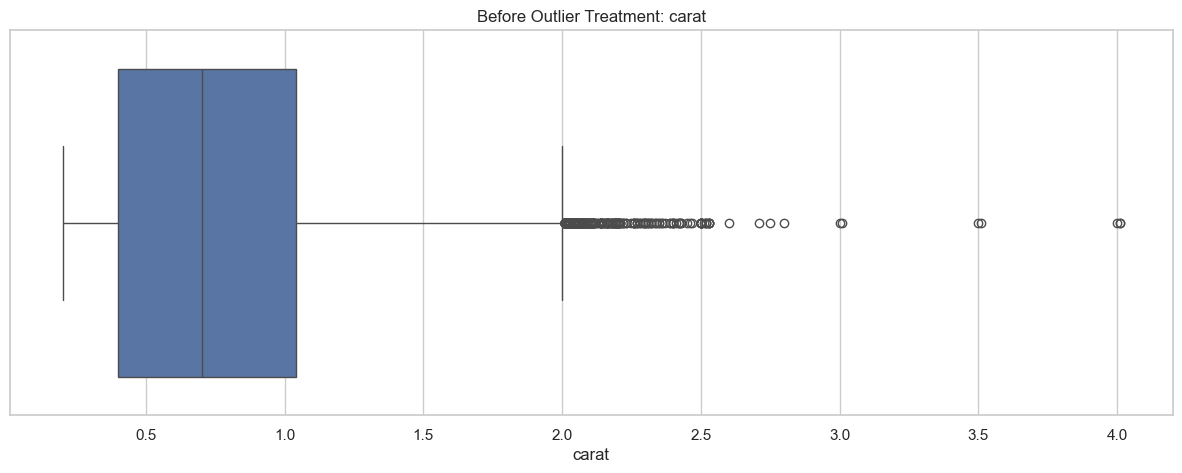

[carat] Outliers before: 379, after: 0


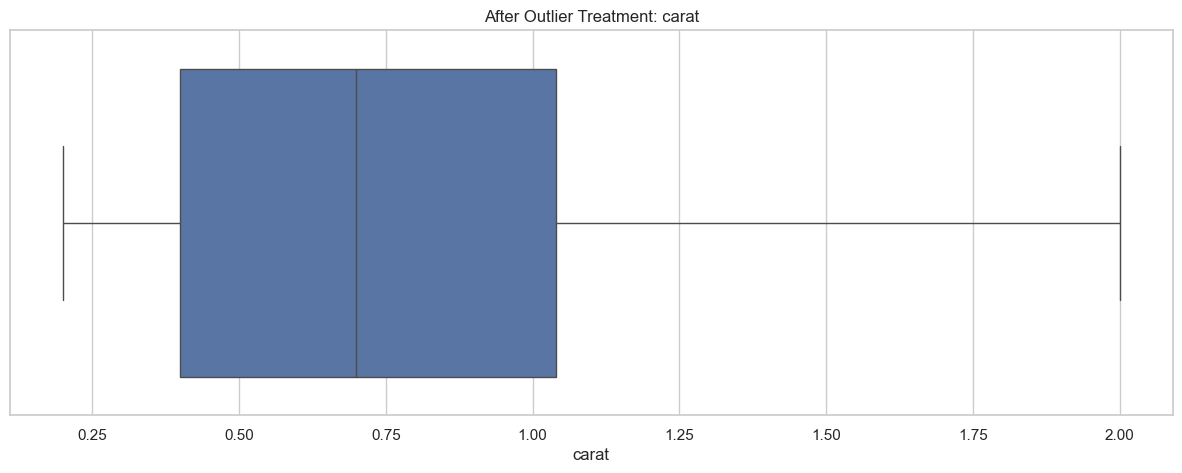

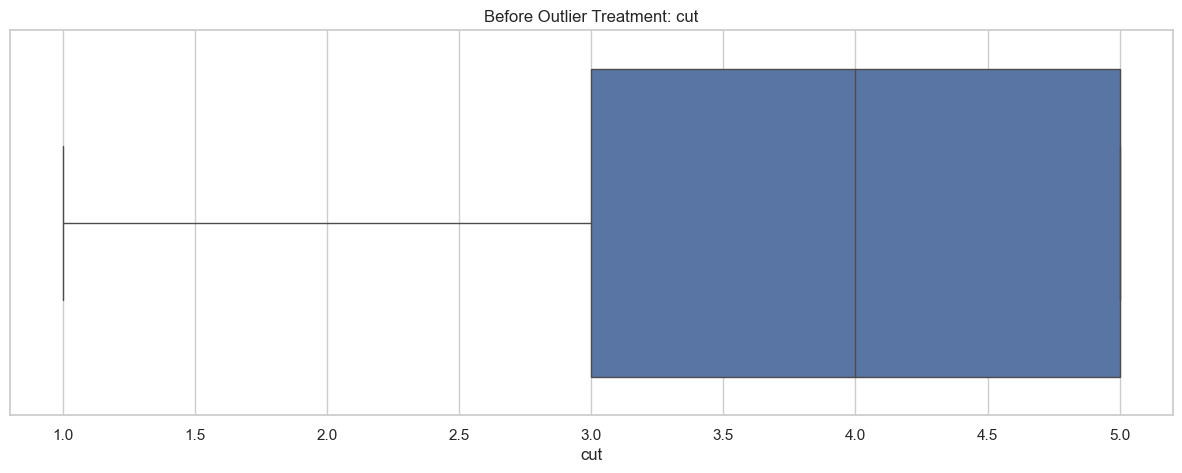

[cut] Outliers before: 0, after: 0


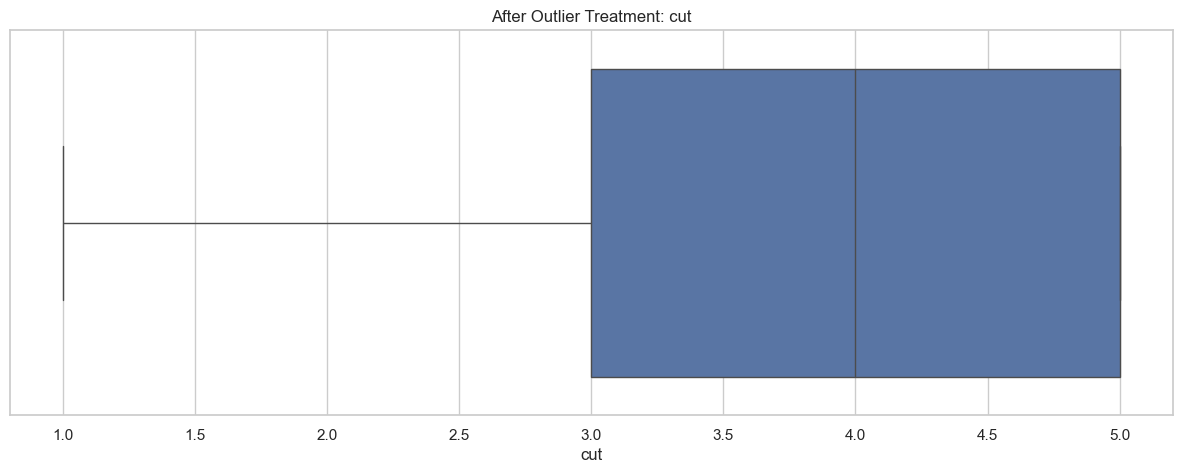

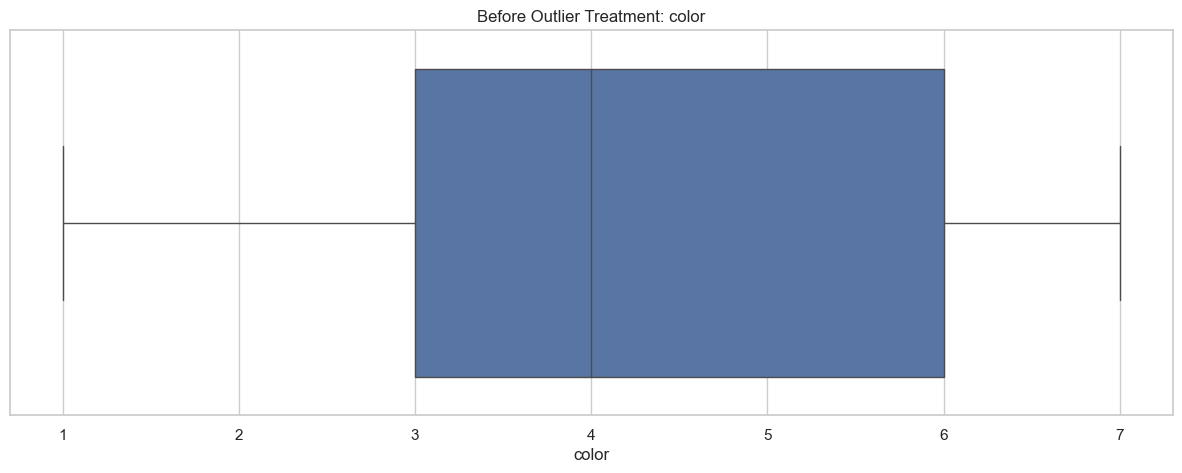

[color] Outliers before: 0, after: 0


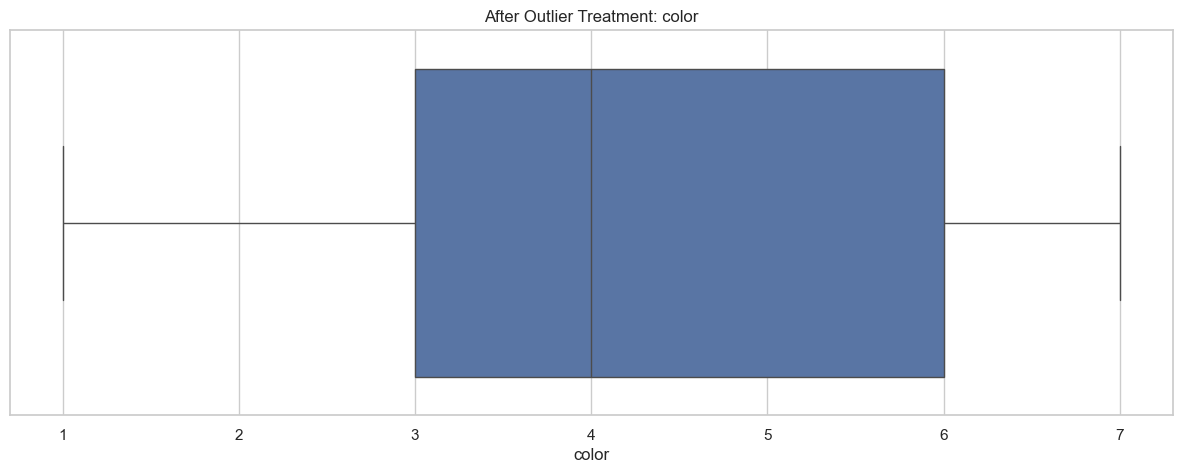

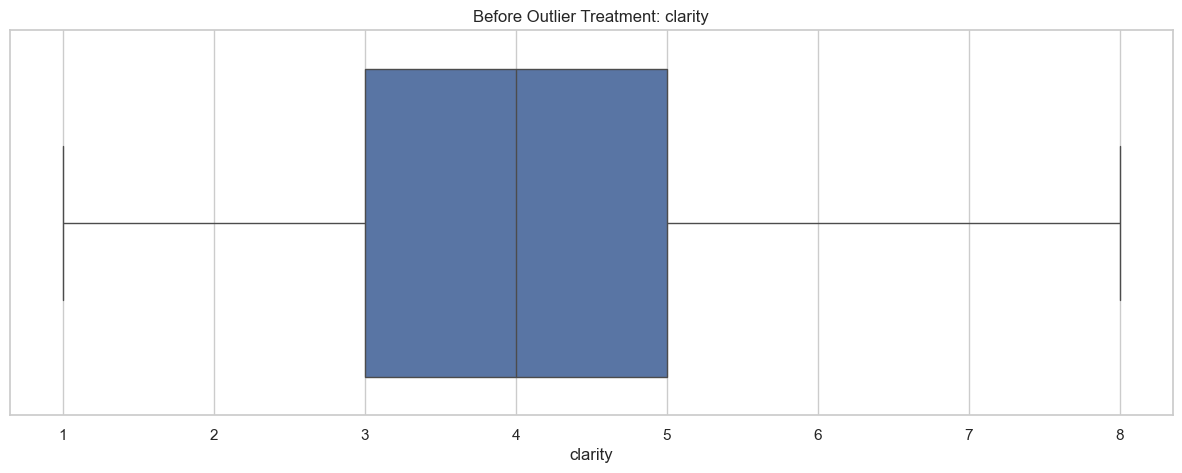

[clarity] Outliers before: 0, after: 0


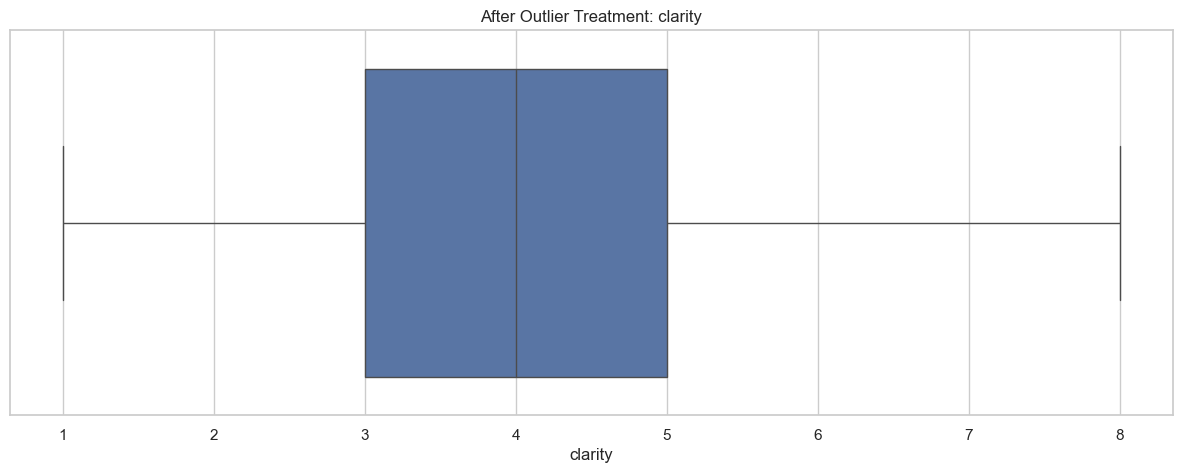

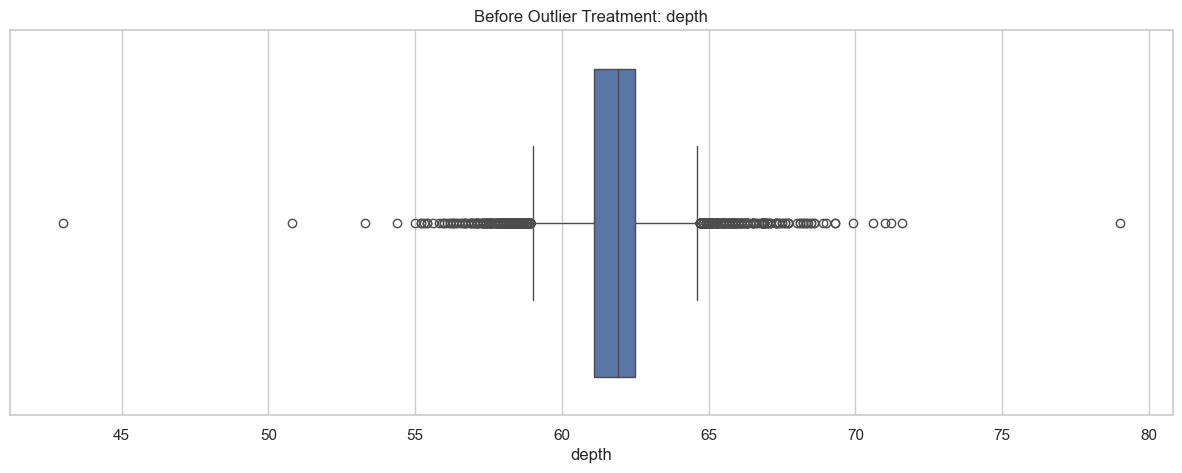

[depth] Outliers before: 622, after: 0


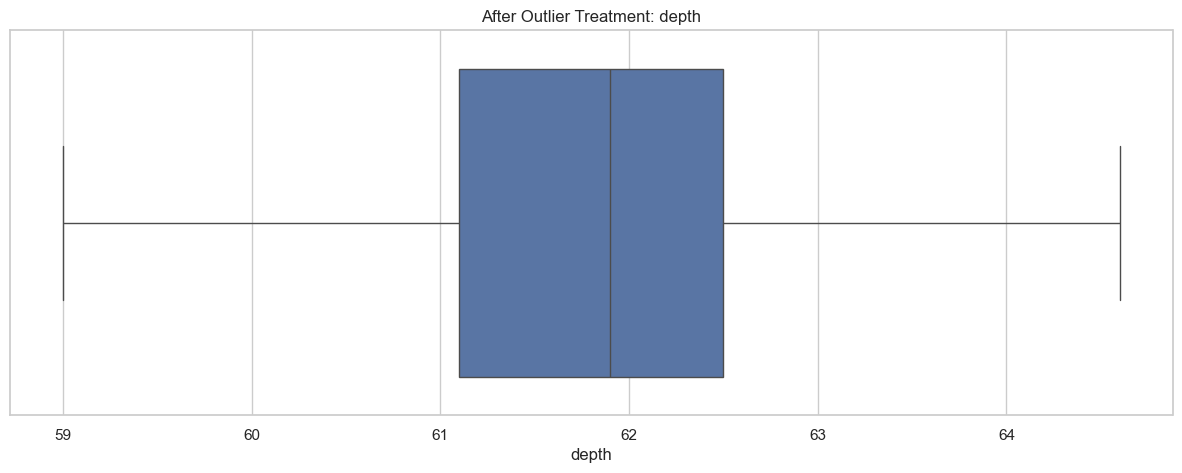

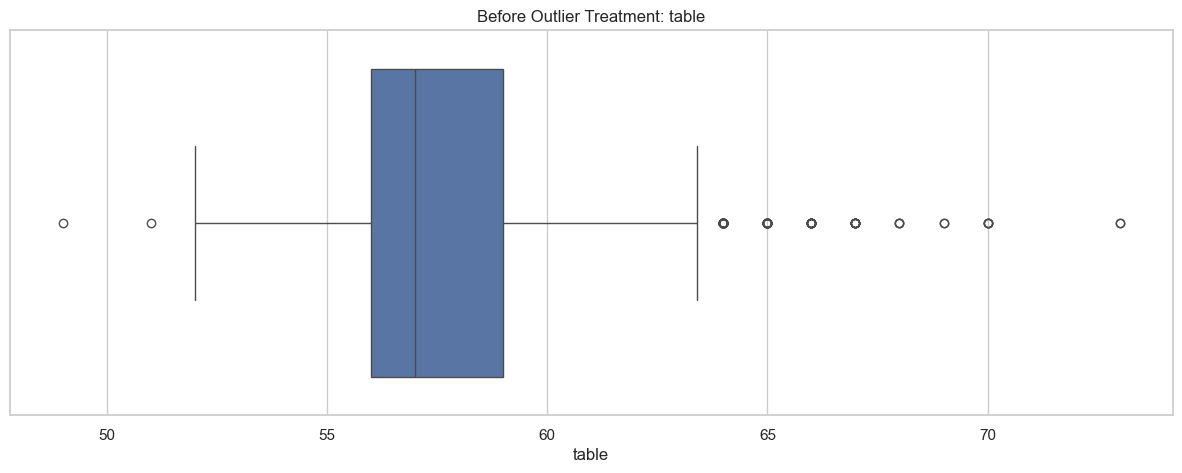

[table] Outliers before: 126, after: 0


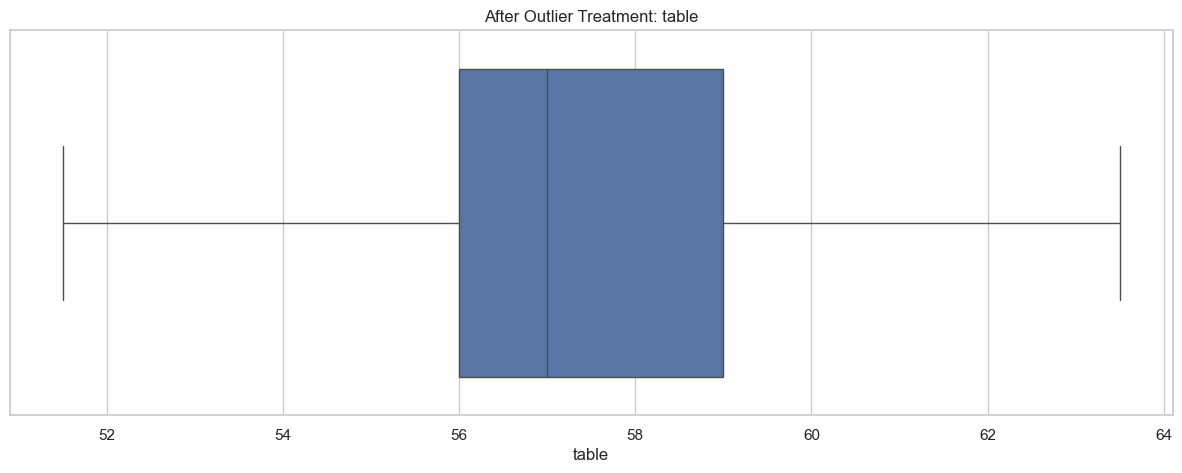

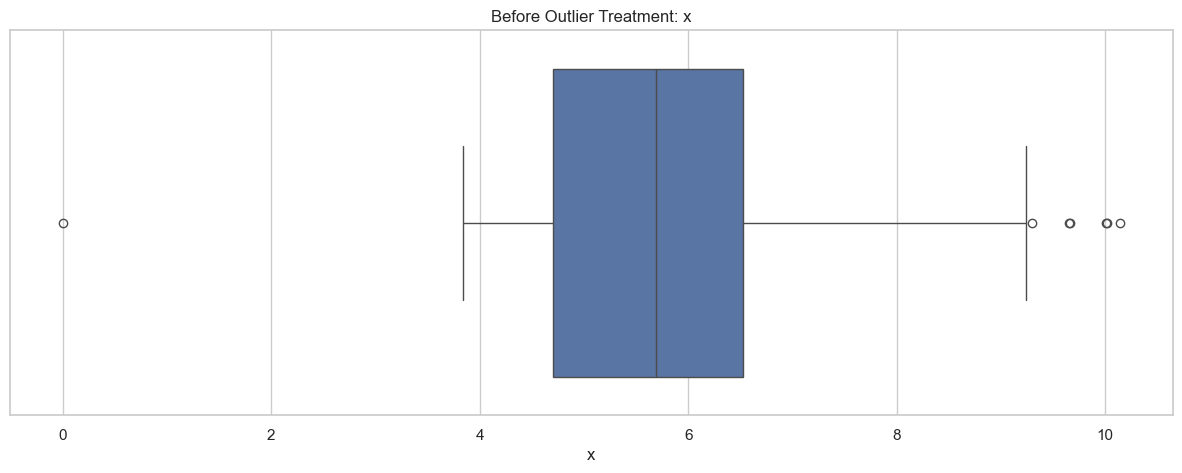

[x] Outliers before: 7, after: 0


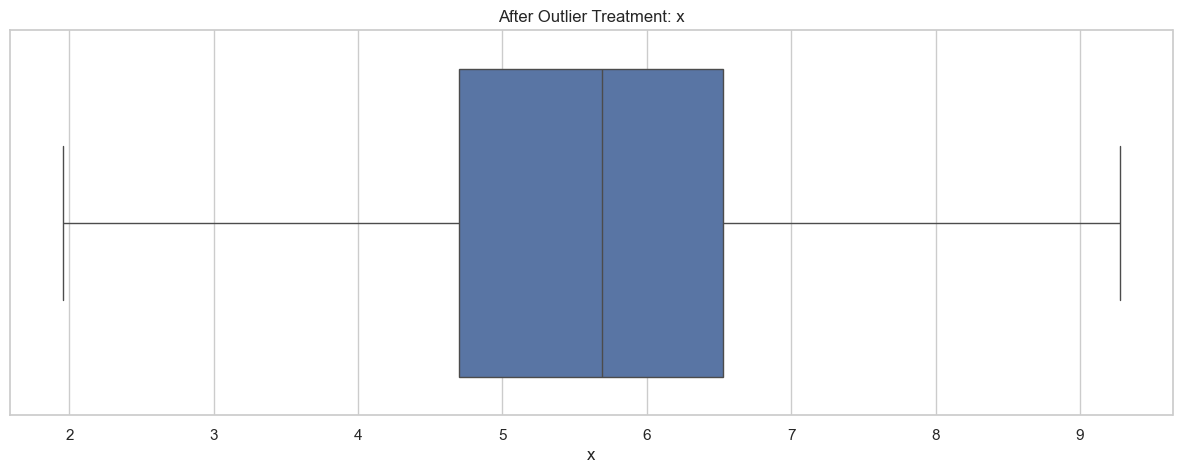

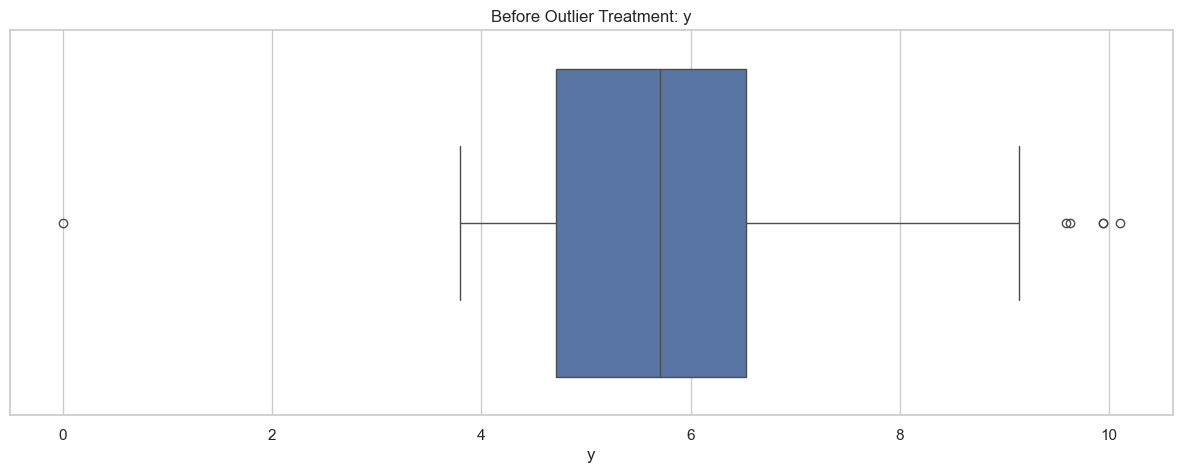

[y] Outliers before: 6, after: 0


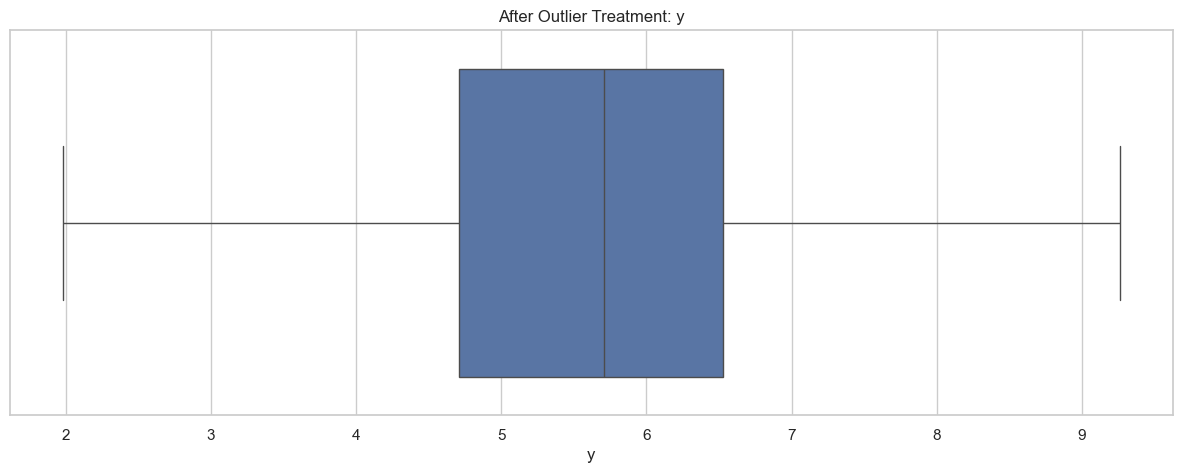

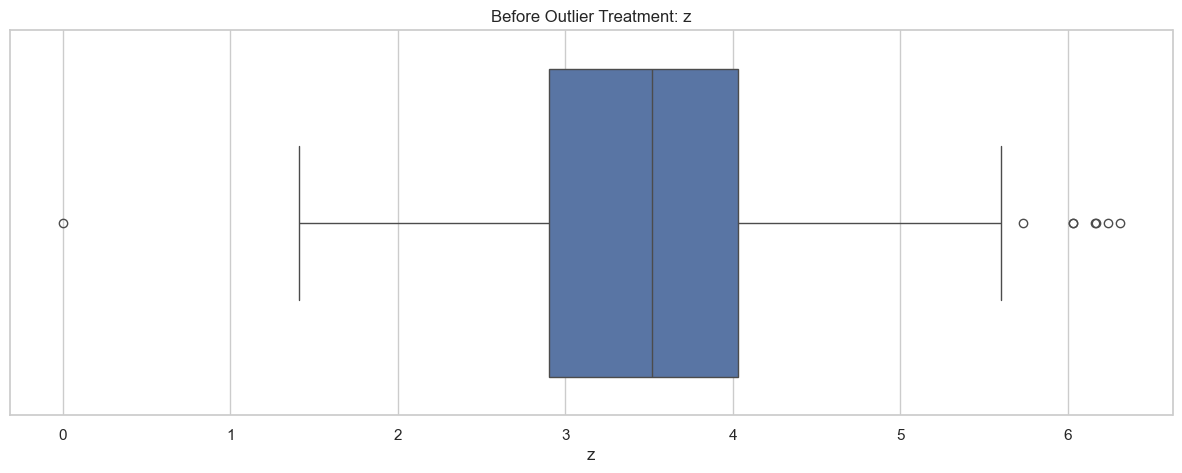

[z] Outliers before: 8, after: 0


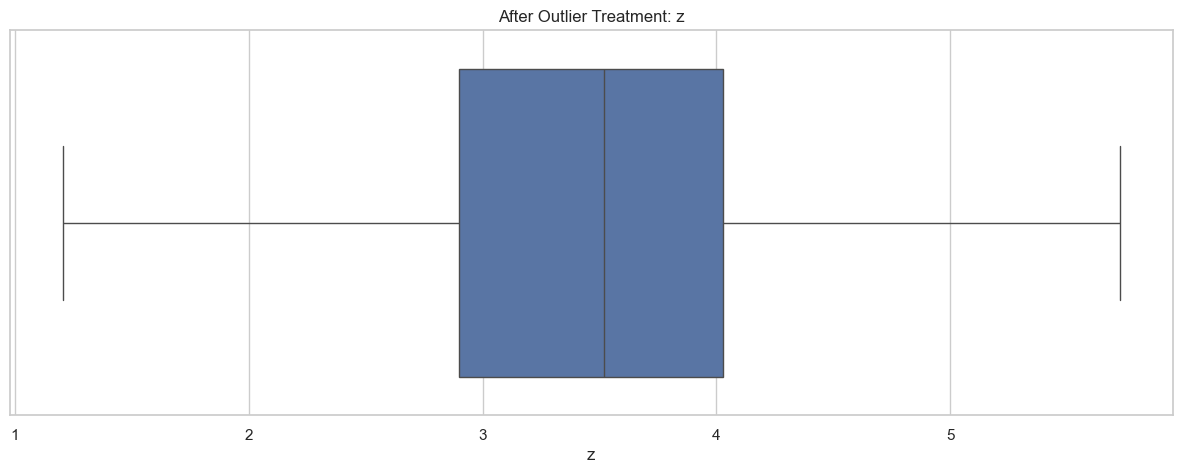

In [36]:
for i in X_test.columns:
    treat_outliers_iqr(X_test, i)

### Observation
**What was done:** Outliers were found with the **IQR rule** (anything below Q1 - 1.5 x IQR or above Q3 + 1.5 x IQR) and **clipped** to those limits instead of deleting rows. Box plots were drawn before and after for every column, on both the training and test sets.

| Column | Outliers (train) | Outliers (test) |
|---|---|---|
| carat | 1,510 | 379 |
| depth | 2,020 | 622 |
| table | 479 | 126 |
| x | 25 | 7 |
| y | 24 | 6 |
| z | 42 | 8 |
| cut, color, clarity | 0 | 0 |

**What the plots show:**
- **Before:** `carat` has a long line of dots beyond 2 carats (up to 5). `depth` has dots on both sides (from about 43 to 79). `y` and `z` have a few isolated points far from everything else (near 59 and 32), plus zeros.
- **After:** all dots are gone and each whisker ends exactly at its limit: `carat` is capped at about 2.0, `depth` sits between about 58.75 and 64.75, `y` between about 2 and 9.3, and `z` between about 1.2 and 5.7. The zero values in `y` and `z` were lifted up to the lower limit.
- `carat` and `depth` account for most of the clipped values.

**Points to be aware of:**
- Capping `carat` at 2.0 changes about 3.5% of the training rows (1,510 of 43,152). These are real, expensive diamonds rather than errors, so this squeezes the top of the price range.
- `X_train_scaled` and `X_test_scaled` were created **before** this step, so the four models in Section 8 were trained on unclipped data. Only the tuned model in Section 10 uses the clipped `X_train`.
- The test set was clipped using its **own** quartiles, not the training quartiles, which is not the cleanest practice.

## 8. Train Regression Models

### Model 1: Linear Regression

In [37]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
y_pred_linear = linear_model.predict(X_test_scaled)

### Model 2: KNN Regression

In [38]:
knn_model = KNeighborsRegressor()
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

### Model 3: Decision Tree Regression

In [39]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

### Model 4: Random Forest Regression

In [40]:
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

**Observation:** Four models were trained on the scaled training data: Linear Regression, KNN (default 5 neighbours), Decision Tree and Random Forest (all with default settings). Each one predicted the prices of the 10,788 test diamonds, and these predictions are compared in the next section.

## 9. Model Evaluation and Comparison

Because this is a regression problem, model performance is evaluated using **MAE, RMSE, and R²**, not classification accuracy.

In [41]:
def evaluate_model(model_name, y_true, y_pred):
    return {
        'Model': model_name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

results = pd.DataFrame([
    evaluate_model('Linear Regression', y_test, y_pred_linear),
    evaluate_model('KNN Regression', y_test, y_pred_knn),
    evaluate_model('Decision Tree', y_test, y_pred_dt),
    evaluate_model('Random Forest', y_test, y_pred_rf)
]).sort_values('RMSE')

results

,Model,MAE,RMSE,R2
3,Random Forest,267.417021,542.468917,0.981489
1,KNN Regression,376.567037,718.029689,0.967568
2,Decision Tree,355.786383,733.377751,0.966167
0,Linear Regression,803.995810,1224.391917,0.905696


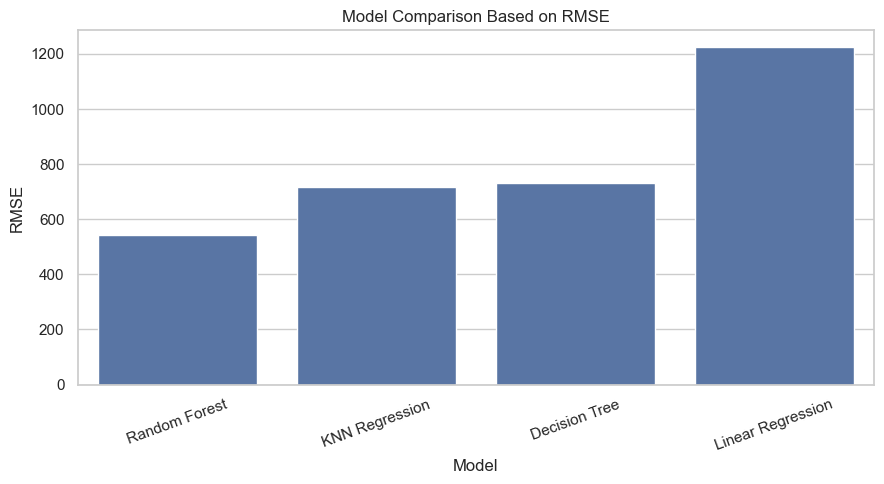

In [42]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results, x='Model', y='RMSE', errorbar=None)
plt.title('Model Comparison Based on RMSE')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

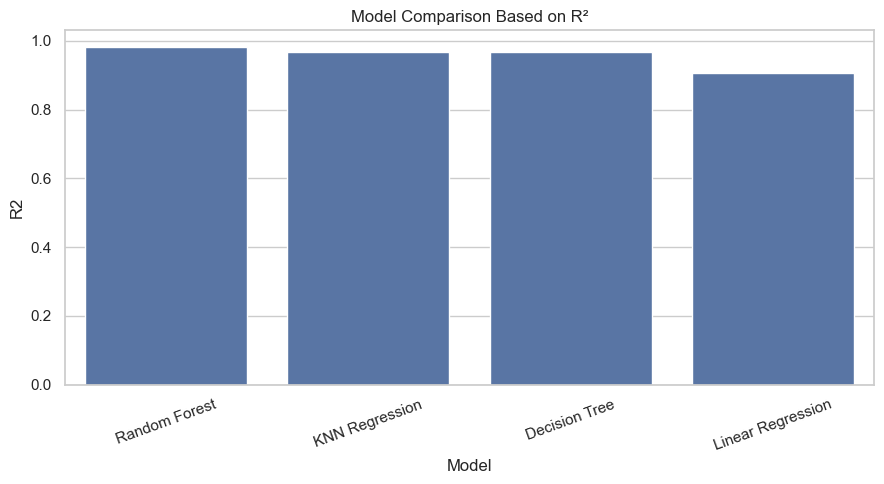

In [43]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results, x='Model', y='R2', errorbar=None)
plt.title('Model Comparison Based on R²')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Model comparison observation
**What was done:** Each model was scored on the test set with MAE (average error in dollars), RMSE (like MAE but punishes big mistakes more) and R² (share of price variation explained; 1.0 is perfect). The two bar charts show RMSE and R².

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Random Forest | 267 | 542 | 0.981 |
| KNN Regression | 377 | 718 | 0.968 |
| Decision Tree | 356 | 733 | 0.966 |
| Linear Regression | 804 | 1,224 | 0.906 |

**What the plots show:**
- In the RMSE chart **Random Forest has the shortest bar** and **Linear Regression the tallest** (about 2.3 times higher).
- In the R² chart all four bars look almost equal (0.91 to 0.98) because the axis starts at 0, so **RMSE and MAE show the differences more clearly than R²**.
- The ranking is Random Forest, then KNN, Decision Tree, and Linear Regression last.

**What it means:**
- The non-linear models beat Linear Regression, which matches the curved price-vs-size scatter plots in Section 4.
- Random Forest is the best on all three metrics: its predictions are off by about **$267 on average**.
- RMSE is larger than MAE for every model, so a few large errors exist (most likely on expensive diamonds).
- These scores come from a single train/test split on scaled, unclipped data.

## 10. Hyperparameter Tuning for Random Forest

In [46]:
param_dist = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=1
    ),
    param_distributions=param_dist,
    n_iter=6,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=1,
    pre_dispatch=1
)

random_search.fit(X_train, y_train)

best_regressor = random_search.best_estimator_

print('Best Parameters:')
print(random_search.best_params_)

print('Best CV RMSE:', -random_search.best_score_)

Best Parameters:
{'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best CV RMSE: 571.8946168760727


### Observation
**What was done:** `RandomizedSearchCV` tried 6 random combinations of Random Forest settings, scoring each with 3-fold cross-validation on the clipped training data (`X_train`) using RMSE.

**What the output shows:**
- Best settings: `n_estimators=150`, `max_depth=20`, `min_samples_split=2`, `min_samples_leaf=1`, `max_features='sqrt'`.
- The best cross-validated RMSE is about **$572**, which is slightly *worse* than the default Random Forest's test RMSE of about $542. This is not a strict like-for-like comparison, but it suggests this small search did not improve the model. `max_features='sqrt'` lets each split see only 3 of the 9 features, which may not suit data where a few columns matter most.

## 11. Evaluate Tuned Random Forest

In [47]:
predictions = best_regressor.predict(X_test_scaled)

tuned_results = evaluate_model('Tuned Random Forest', y_test, predictions)
pd.DataFrame([tuned_results])

,Model,MAE,RMSE,R2
0,Tuned Random Forest,1869.842128,2790.579441,0.510133


### Observation
**What the output shows:** The tuned Random Forest scored **MAE ~$1,870, RMSE ~$2,791 and R² = 0.51**. This is far worse than the default Random Forest (MAE ~$267, RMSE ~$542, R² = 0.981) and even worse than Linear Regression. It also does not agree with the model's own cross-validated RMSE of about $572.

**Likely cause (a pipeline mismatch, not a weak model):**
- The tuned model was **trained on `X_train`** (original units, outliers clipped).
- But it is **evaluated on `X_test_scaled`** (standardized values).
- Tree models split on real-unit thresholds (for example, carat < 0.9), so feeding them standardized numbers sends most rows down the wrong branches.

**Suggested fix:** predict with `best_regressor.predict(X_test)` instead of `X_test_scaled`. This has not been re-run here, so treat these numbers as **not valid** for judging the tuned model until it is.

### Actual vs Predicted Prices

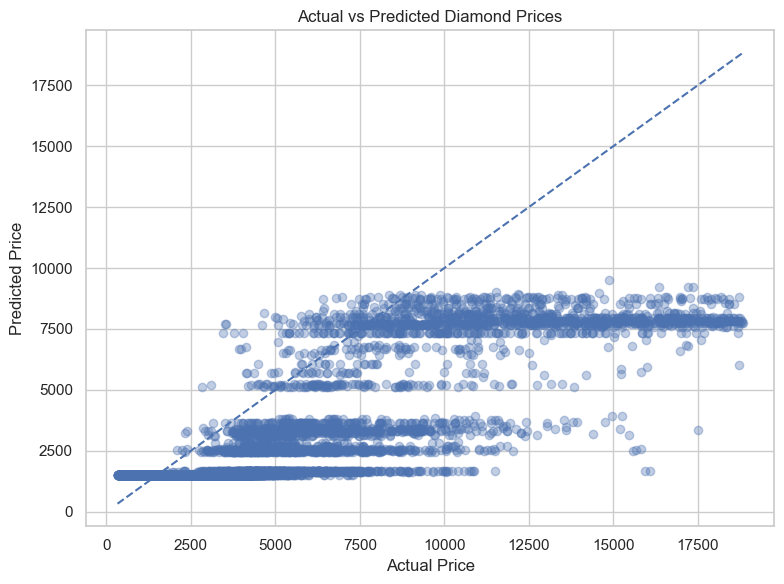

In [48]:
min_value = min(y_test.min(), predictions.min())
max_value = max(y_test.max(), predictions.max())

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.35)
plt.plot([min_value, max_value], [min_value, max_value], linestyle='--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Diamond Prices')
plt.tight_layout()
plt.show()

**Observation:**
- **What was done:** A scatter plot of actual test prices (x-axis) against the tuned model's predicted prices (y-axis). The dashed diagonal is where perfect predictions would fall.
- **What the plot shows:** The points are **far from the diagonal**. Predictions line up in flat horizontal bands at about $1,500, $2,500 to $3,500, $5,000 and $7,500 to $8,500, and the model **never predicts above about $9,500** even though real prices reach about $18,800. Diamonds that actually cost $10,000 to $18,000 are all predicted at roughly $7,500 to $8,500, a large under-prediction at the high end.
- **What it means:** The band-like pattern is typical of a model receiving inputs in the wrong units, which fits the scaled-vs-unscaled mismatch described above. This plot points to a pipeline problem rather than to Random Forest being unsuitable.

## 12. Feature Importance

In [49]:

feature_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': best_regressor.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance

,Feature,Importance
0,carat,0.327780
7,y,0.276067
6,x,0.186306
8,z,0.109010
3,clarity,0.057797
2,color,0.030434
4,depth,0.005384
5,table,0.004449
1,cut,0.002772


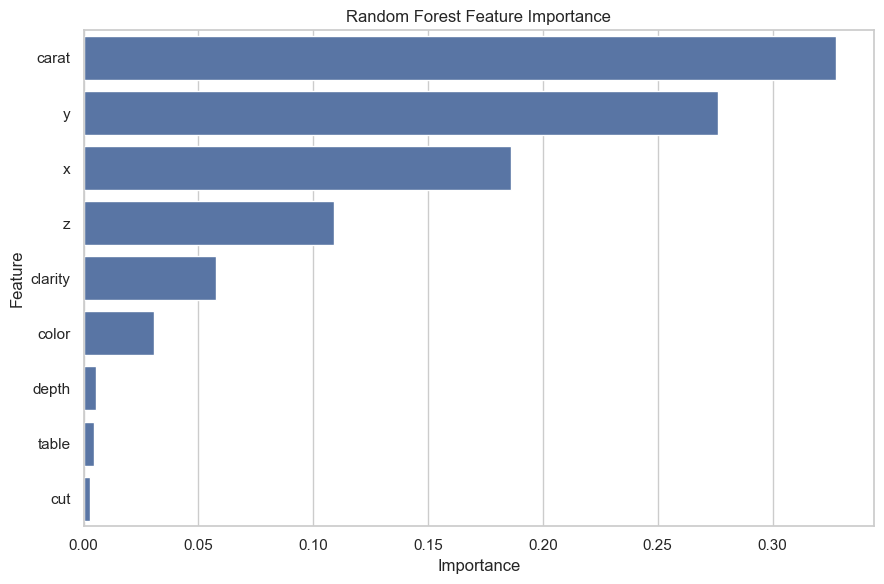

In [50]:
plt.figure(figsize=(9, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', errorbar=None)
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

### Observation
**What was done:** The importance score of each feature was taken from the tuned Random Forest (the scores add up to 1) and plotted as a horizontal bar chart. These scores come from how the trees were trained, so they are not affected by the evaluation mismatch above.

**What the plot shows:**

| Feature | Importance |
|---|---|
| carat | 0.328 |
| y | 0.276 |
| x | 0.186 |
| z | 0.109 |
| clarity | 0.058 |
| color | 0.030 |
| depth | 0.005 |
| table | 0.004 |
| cut | 0.003 |

- The four size features (`carat`, `y`, `x`, `z`) together hold about **90%** of the importance.
- `clarity` and `color` add a modest amount; `depth`, `table` and `cut` are close to zero.

**What it means:**
- This agrees with the EDA: size has the strongest link with price, while `depth` and `table` showed almost no relationship.
- `cut` being near zero matches the odd bar chart in Section 4, where the best cut was not the most expensive.
- `carat`, `x`, `y` and `z` are correlated at 0.95 to 0.98, so they share the importance between them. Their order (for example `y` above `x`) should not be over-read.
- Feature importance shows what the model *used*, not what *causes* price.

## 13. Final Conclusion

This project explored the diamond dataset (53,940 diamonds) and compared four regression models for predicting price.

### Key Takeaways
- **Size drives price.** `carat` (r = 0.92) and the dimensions `x`, `y`, `z` (r = 0.86 to 0.88) are strongly linked to price, while `depth` and `table` are not. The size columns are highly correlated with each other (0.95 to 0.98).
- **Quality grades alone mislead.** Average price was highest for Premium cut, J colour and SI2 clarity, which are not the best grades, because carat is mixed in. Grades should be read together with size.
- **Data quality needs care.** There are no missing values, but `x`, `y` and `z` contain zeros and a few impossible extremes (about 32 and 59), and 146 duplicate rows were kept.
- **Best baseline: Random Forest.** MAE about $267, RMSE about $542 and R² = 0.981 on the test set, ahead of KNN, Decision Tree and Linear Regression (R² = 0.906). Non-linear models suit the curved price-vs-size pattern.
- **Tuned Random Forest result is not reliable yet.** Its test score (R² = 0.51) comes from predicting on scaled test data with a model trained on unscaled data. Re-evaluating on `X_test` is the first thing to do.
- **Feature importance:** `carat`, `y`, `x` and `z` hold about 90% of the importance, and `cut` is almost unused.

### Improvements to try next
- Fix the tuned-model evaluation (`best_regressor.predict(X_test)`).
- Correct the `cut` order (Ideal as the best grade) in the encoding.
- Create the scaled data *after* outlier treatment, and clip the test set with the training limits.
- Replace the `x`, `y`, `z` zeros with proper treatment, and think twice before capping `carat` at 2.0.
- Use a larger search for tuning (more than 6 combinations) and try the log of `price` as the target.